# Text/Transcripts and Polls EDA

Role focus: debate transcripts and polls. Audio features are used only where they make the transcript analysis defensible, mainly speaker labelling and speech-rate sanity checks.

Questions this notebook answers:
1. How much does each candidate speak, and how long are the transcript segments?
2. Which words, phrases, and embedding topics distinguish each candidate?
3. How did poll results evolve over time by agency and candidate?
4. Do transcript embeddings show similar candidates, debates, or parties?

Required key plots:
1. Poll timeline chart (Section 5)
2. Transcript length distributions (Section 3)
3. Similarity heatmap between candidates (Section 6)

Extra safeguards added here:
- candidate-label diagnostics before drawing language conclusions
- normalized word/phrase frequencies rather than only raw counts
- topic and poll analyses labelled as suggestive, not causal


In [1]:
import os
import re
from collections import Counter
from itertools import combinations, permutations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)


## 1. Loading transcripts, polls, and party labels

In [2]:
FEAT_DIR = 'Project_Features'

# Person 4 deliverable is debate-specific. Speech pkls also include
# Telejornal_* newscast files (Person 3's territory) — filter those out
# so candidate-level analysis is well-defined.
speech_files = sorted(
    f for f in os.listdir(FEAT_DIR)
    if f.endswith('_speech.pkl') and not f.startswith('Telejornal_')
)
speech_dfs = []
for f in speech_files:
    df = pd.read_pickle(os.path.join(FEAT_DIR, f))
    df['video'] = f.replace('_speech.pkl', '')
    speech_dfs.append(df)
speech = pd.concat(speech_dfs, ignore_index=True)

polls = pd.read_pickle(os.path.join(FEAT_DIR, 'polls_timeline.pkl'))
parties = pd.read_pickle(os.path.join(FEAT_DIR, 'candidate_party.pkl'))
candidate_to_party = dict(zip(parties['Candidate'], parties['Party']))

print(f'{len(speech)} debate speech segments across {speech["video"].nunique()} debates')
print(f'speech columns: {list(speech.columns)}')
print(f'\npolls: {polls.shape}, sources: {polls["Poll_source"].nunique()}')
print('parties:')
print(parties)

843 debate speech segments across 28 debates
speech columns: ['timestamp', 'duration', 'transcript', 'text_embedding', 'video']

polls: (13, 10), sources: 5
parties:
           Candidate        Party
0       Gouveia_Melo  Independent
1     Marques_Mendes      PSD+CDS
2             Seguro           PS
3            Ventura           CH
4  Cotrim_Figueiredo           IL
5             Filipe          CDU
6            Martins           BE
7              Pinto            L


## 2. Assigning and validating candidate labels

The `*_speech.pkl` files have transcripts and text embeddings, but no speaker/candidate column. The companion `*_audio.pkl` files contain 512-dim `speak_embeddings` for the same diarized segments.

Workflow:
1. Cluster audio speaker embeddings inside each debate.
2. Constrain the mapping to the two candidates named in the file plus `interviewer`.
3. Iteratively match same-candidate voice centroids across debates.
4. Join candidate labels back to speech rows on `(video, timestamp)`.
5. Run diagnostics before using those labels for candidate-level language claims.


In [3]:
CANDIDATES = [
    'Cotrim_Figueiredo', 'Filipe', 'Gouveia_Melo',
    'Marques_Mendes', 'Martins', 'Pinto', 'Seguro', 'Ventura',
]

audio_files = sorted(f for f in os.listdir(FEAT_DIR) if f.endswith('_audio.pkl'))
audio_dfs = []
for f in audio_files:
    df = pd.read_pickle(os.path.join(FEAT_DIR, f))
    df['video'] = f.replace('_audio.pkl', '')
    audio_dfs.append(df)
audio = pd.concat(audio_dfs, ignore_index=True)
audio = audio.rename(columns={'time stamp': 'timestamp'})  # align with speech

def extract_candidates(video_name):
    """Return (candA, candB) parsed from filename like 'A_vs_B_Month_Day'."""
    for c in CANDIDATES:
        if video_name.startswith(c):
            rest = video_name[len(c) + len('_vs_'):]
            for c2 in CANDIDATES:
                if rest.startswith(c2):
                    return c, c2
    return None, None

print(f'{len(audio)} audio segments  |  {audio["video"].nunique()} debates')
print('Sanity:', extract_candidates('Ventura_vs_Filipe_December_13'))

2656 audio segments  |  28 debates
Sanity: ('Ventura', 'Filipe')


In [4]:
debate_state = {}
for video_name, group in audio.groupby('video'):
    embs = np.stack(group['speak_embeddings'].values)
    best = None
    for k in (2, 3, 4):
        if len(embs) <= k:
            continue
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(embs)
        sil = silhouette_score(embs, labels, metric='cosine')
        if best is None or sil > best['silhouette']:
            best = {
                'k': k, 'silhouette': sil, 'labels': labels,
                'centroids': km.cluster_centers_, 'index': group.index,
            }
    debate_state[video_name] = best

k_dist = pd.Series([s['k'] for s in debate_state.values()]).value_counts().sort_index()
mean_sil = float(np.mean([s['silhouette'] for s in debate_state.values()]))
print('k chosen across', len(debate_state), 'debates:')
print(k_dist.to_string())
print(f'\nMean silhouette (cosine): {mean_sil:.3f}')

k chosen across 28 debates:
2     1
3    27

Mean silhouette (cosine): 0.548


In [5]:
def cosine(u, v):
    nu, nv = np.linalg.norm(u), np.linalg.norm(v)
    if nu == 0 or nv == 0:
        return 0.0
    return float(np.dot(u, v) / (nu * nv))


def init_mapping(state, cA, cB):
    sizes = np.bincount(state['labels'], minlength=state['k'])
    by_size = list(np.argsort(-sizes))
    mapping = {int(by_size[0]): cA, int(by_size[1]): cB}
    for c in by_size[2:]:
        mapping[int(c)] = 'interviewer'
    return mapping


assignments = {}
for video_name, state in debate_state.items():
    cA, cB = extract_candidates(video_name)
    if cA is None or cB is None:
        continue
    assignments[video_name] = init_mapping(state, cA, cB)


def global_centroids(assignments, debate_state):
    g = {c: [] for c in CANDIDATES}
    for video_name, mapping in assignments.items():
        st = debate_state[video_name]
        for cluster_id, label in mapping.items():
            if label in g:
                g[label].append(st['centroids'][cluster_id])
    return {c: np.mean(v, axis=0) for c, v in g.items() if v}


def best_mapping(state, cA, cB, gc):
    # Returns mapping plus a confidence gap: best score minus second-best score.
    k = state['k']
    if cA not in gc or cB not in gc:
        return None, -np.inf, np.nan
    gA, gB = gc[cA], gc[cB]
    best_m, best_s, second_s = None, -np.inf, -np.inf
    for a, b in permutations(range(k), 2):
        s = cosine(state['centroids'][a], gA) + cosine(state['centroids'][b], gB)
        if s > best_s:
            second_s = best_s
            best_s = s
            best_m = {a: cA, b: cB}
            for c in range(k):
                if c not in (a, b):
                    best_m[c] = 'interviewer'
        elif s > second_s:
            second_s = s
    return best_m, best_s, best_s - second_s


assignment_scores = {}
assignment_gaps = {}
for it in range(15):
    gc = global_centroids(assignments, debate_state)
    flips = 0
    new_assignments = {}
    for video_name, state in debate_state.items():
        cA, cB = extract_candidates(video_name)
        if cA is None:
            new_assignments[video_name] = assignments.get(video_name)
            continue
        m, score, gap = best_mapping(state, cA, cB, gc)
        if m is None:
            new_assignments[video_name] = assignments[video_name]
            continue
        if m != assignments[video_name]:
            flips += 1
        new_assignments[video_name] = m
        assignment_scores[video_name] = score
        assignment_gaps[video_name] = gap
    assignments = new_assignments
    print(f'iter {it+1}: {flips} flips')
    if flips == 0:
        break

final_gc = global_centroids(assignments, debate_state)
within, between = [], []
for video_name, mapping in assignments.items():
    st = debate_state[video_name]
    for cluster_id, label in mapping.items():
        if label not in final_gc:
            continue
        v = st['centroids'][cluster_id]
        within.append(cosine(v, final_gc[label]))
        for other, gv in final_gc.items():
            if other != label:
                between.append(cosine(v, gv))

print(f'\nMean same-candidate centroid cosine: {np.mean(within):.3f}')
print(f'Mean different-candidate centroid cosine: {np.mean(between):.3f}')
print(f'Voice-separation gap: {np.mean(within) - np.mean(between):.3f}')


iter 1: 17 flips
iter 2: 1 flips
iter 3: 4 flips
iter 4: 0 flips

Mean same-candidate centroid cosine: 0.960
Mean different-candidate centroid cosine: 0.288
Voice-separation gap: 0.672


In [6]:
audio = audio.copy()
audio['candidate'] = 'unknown'
for video_name, state in debate_state.items():
    mapping = assignments.get(video_name)
    if mapping is None:
        continue
    cluster_to_label = np.array([mapping[c] for c in range(state['k'])], dtype=object)
    audio.loc[state['index'], 'candidate'] = cluster_to_label[state['labels']]
audio['party'] = audio['candidate'].map(candidate_to_party).fillna('interviewer')

# Speech timestamps are a strict subset of audio timestamps -> merge on (video, timestamp).
audio_label_features = audio[[
    'video', 'timestamp', 'candidate', 'party',
    'speechrate', 'articulationrate', 'meanF0Hz'
]].copy()

speech_lab = speech.merge(audio_label_features, on=['video', 'timestamp'], how='left')
print(f'Speech rows after merge: {len(speech_lab)} (input {len(speech)})')
print(f'Unmatched (NaN candidate): {speech_lab["candidate"].isna().sum()}')
print('\nSegments per candidate:')
print(speech_lab['candidate'].value_counts().to_string())


Speech rows after merge: 843 (input 843)
Unmatched (NaN candidate): 0

Segments per candidate:
candidate
interviewer          117
Marques_Mendes       110
Pinto                108
Martins              101
Filipe                98
Ventura               98
Seguro                94
Cotrim_Figueiredo     92
Gouveia_Melo          25


In [7]:
# Keep basic transcript metrics available before candidate-level diagnostics.
speech_lab['word_count'] = speech_lab['transcript'].fillna('').str.split().str.len()
speech_lab['char_count'] = speech_lab['transcript'].fillna('').str.len()
speech_lab['words_per_sec'] = speech_lab['word_count'] / speech_lab['duration'].replace(0, np.nan)

candidate_coverage = (speech_lab.groupby('candidate')
    .agg(segments=('transcript', 'count'),
         total_words=('word_count', 'sum'),
         total_seconds=('duration', 'sum'),
         mean_words=('word_count', 'mean'))
    .sort_values('total_words', ascending=False))
candidate_coverage['word_share_pct'] = 100 * candidate_coverage['total_words'] / candidate_coverage['total_words'].sum()
candidate_coverage['total_minutes'] = candidate_coverage['total_seconds'] / 60
print('Candidate-level transcript coverage:')
display(candidate_coverage.round({'total_seconds': 1, 'mean_words': 1, 'word_share_pct': 1, 'total_minutes': 1}))

rows = []
for video_name, group in speech_lab.groupby('video'):
    cA, cB = extract_candidates(video_name)
    counts = group['candidate'].value_counts().to_dict()
    words = group.groupby('candidate')['word_count'].sum().to_dict()
    total_words = group['word_count'].sum()
    expected_words = [words.get(c, 0) for c in (cA, cB)]
    expected_counts = [counts.get(c, 0) for c in (cA, cB)]
    min_word_share = min(expected_words) / total_words if total_words else np.nan
    rows.append({
        'video': video_name,
        'expected_candidates': f'{cA} | {cB}',
        'segments': len(group),
        'candidateA_segments': expected_counts[0],
        'candidateB_segments': expected_counts[1],
        'interviewer_segments': counts.get('interviewer', 0),
        'candidateA_words': expected_words[0],
        'candidateB_words': expected_words[1],
        'interviewer_words': words.get('interviewer', 0),
        'min_candidate_word_share': min_word_share,
        'mapping_gap': assignment_gaps.get(video_name, np.nan),
    })

debate_label_diag = pd.DataFrame(rows).sort_values('min_candidate_word_share')
print('Lowest participant coverage by debate (small values need caveats):')
display(debate_label_diag.head(12).round({'min_candidate_word_share': 3, 'mapping_gap': 3}))

assignment_diag = []
for video_name, state in debate_state.items():
    sizes = np.bincount(state['labels'], minlength=state['k'])
    mapping = assignments.get(video_name, {})
    assignment_diag.append({
        'video': video_name,
        'k': state['k'],
        'silhouette': state['silhouette'],
        'mapping_gap': assignment_gaps.get(video_name, np.nan),
        'cluster_sizes': list(map(int, sizes)),
        'mapping': {int(k): v for k, v in mapping.items()},
    })
assignment_diag = pd.DataFrame(assignment_diag).sort_values('mapping_gap')
print('Most ambiguous voice-cluster mappings:')
display(assignment_diag.head(10).round({'silhouette': 3, 'mapping_gap': 3}))

low_coverage = debate_label_diag[debate_label_diag['min_candidate_word_share'] < 0.10]
if len(low_coverage):
    print('\nWarning: some debates have one expected candidate below 10% of transcript words.')
    print('Candidate-level language conclusions for those rows should be treated as lower confidence.')
    print(low_coverage[['video', 'expected_candidates', 'min_candidate_word_share']].to_string(index=False))


Candidate-level transcript coverage:


,segments,total_words,total_seconds,mean_words,word_share_pct,total_minutes
candidate,,,,,,
Ventura,98,23415,5763.2,238.9,20.0,96.1
Pinto,108,18731,5252.2,173.4,16.0,87.5
Filipe,98,13932,4191.9,142.2,11.9,69.9
Martins,101,13377,4035.1,132.4,11.4,67.3
Cotrim_Figueiredo,92,12899,3767.6,140.2,11.0,62.8
Marques_Mendes,110,11396,3695.8,103.6,9.7,61.6
interviewer,117,10814,3419.7,92.4,9.2,57.0
Seguro,94,10680,3447.4,113.6,9.1,57.5
Gouveia_Melo,25,2084,769.0,83.4,1.8,12.8


Lowest participant coverage by debate (small values need caveats):


,video,expected_candidates,segments,candidateA_segments,candidateB_segments,interviewer_segments,candidateA_words,candidateB_words,interviewer_words,min_candidate_word_share,mapping_gap
8,Gouveia_Melo_vs_Ventura_December_15,Gouveia_Melo | Ventura,21,1,17,3,86,2978,424,0.025,0.411
1,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,Cotrim_Figueiredo | Gouveia_Melo,19,14,1,4,1510,49,317,0.026,0.496
16,Pinto_vs_Gouveia_Melo_November_26,Pinto | Gouveia_Melo,24,14,3,7,2600,253,489,0.076,0.834
20,Seguro_vs_Gouveia_Melo_December_9,Seguro | Gouveia_Melo,17,10,2,5,928,135,492,0.087,0.672
11,Martins_vs_Gouveia_Melo_November_23,Martins | Gouveia_Melo,28,18,5,5,2724,386,410,0.110,0.699
4,Filipe_vs_Gouveia_Melo_December_2,Filipe | Gouveia_Melo,21,10,3,8,1514,281,614,0.117,0.762
7,Filipe_vs_Pinto_December_8,Filipe | Pinto,29,8,15,6,1115,2730,634,0.249,0.502
9,Marques_Mendes_vs_Gouveia_Melo_December_21,Marques_Mendes | Gouveia_Melo,35,20,10,5,2033,894,380,0.270,0.675
17,Pinto_vs_Marques_Mendes_November_29,Pinto | Marques_Mendes,32,16,13,3,2601,1153,284,0.286,0.585
15,Pinto_vs_Cotrim_Figueiredo_November_24,Pinto | Cotrim_Figueiredo,32,16,11,5,2486,1235,465,0.295,0.580


Most ambiguous voice-cluster mappings:


,video,k,silhouette,mapping_gap,cluster_sizes,mapping
27,Ventura_vs_Seguro_November_17,3,0.351,0.288,"[23, 41, 27]","{0: 'Ventura', 1: 'Seguro', 2: 'interviewer'}"
8,Gouveia_Melo_vs_Ventura_December_15,3,0.408,0.411,"[30, 40, 26]","{1: 'Gouveia_Melo', 0: 'Ventura', 2: 'intervie..."
19,Seguro_vs_Filipe_December_19,3,0.496,0.414,"[38, 19, 25]","{0: 'Seguro', 2: 'Filipe', 1: 'interviewer'}"
18,Seguro_vs_Cotrim_Figueiredo_December_17,3,0.393,0.466,"[19, 48, 26]","{1: 'Seguro', 2: 'Cotrim_Figueiredo', 0: 'inte..."
24,Ventura_vs_Filipe_December_13,3,0.475,0.469,"[33, 26, 16]","{1: 'Ventura', 0: 'Filipe', 2: 'interviewer'}"
23,Seguro_vs_Pinto_December_1,3,0.593,0.493,"[36, 34, 25]","{0: 'Seguro', 1: 'Pinto', 2: 'interviewer'}"
1,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,3,0.477,0.496,"[54, 50, 24]","{0: 'Cotrim_Figueiredo', 1: 'Gouveia_Melo', 2:..."
7,Filipe_vs_Pinto_December_8,3,0.507,0.502,"[47, 20, 20]","{0: 'Filipe', 1: 'Pinto', 2: 'interviewer'}"
3,Cotrim_Figueiredo_vs_Ventura_December_19,3,0.391,0.531,"[20, 35, 47]","{2: 'Cotrim_Figueiredo', 1: 'Ventura', 0: 'int..."
6,Filipe_vs_Martins_December_10,3,0.610,0.544,"[36, 26, 31]","{2: 'Filipe', 0: 'Martins', 1: 'interviewer'}"



Candidate-level language conclusions for those rows should be treated as lower confidence.
                                        video              expected_candidates  min_candidate_word_share
          Gouveia_Melo_vs_Ventura_December_15           Gouveia_Melo | Ventura                  0.024656
Cotrim_Figueiredo_vs_Gouveia_Melo_November_20 Cotrim_Figueiredo | Gouveia_Melo                  0.026119
            Pinto_vs_Gouveia_Melo_November_26             Pinto | Gouveia_Melo                  0.075703
            Seguro_vs_Gouveia_Melo_December_9            Seguro | Gouveia_Melo                  0.086817


## 3. Transcript length distributions  *(required key plot #2)*

Volume of speech per segment, debate, and candidate. Useful as a sanity check before any
downstream modelling and as a verbosity comparison across speakers.

In [8]:
# Basic transcript metrics; recomputed here to keep this section self-contained.
speech_lab['word_count'] = speech_lab['transcript'].fillna('').str.split().str.len()
speech_lab['char_count'] = speech_lab['transcript'].fillna('').str.len()
speech_lab['words_per_sec'] = speech_lab['word_count'] / speech_lab['duration'].replace(0, np.nan)

print('Per-segment summary:')
print(speech_lab[['word_count', 'char_count', 'duration', 'words_per_sec']].describe().round(2))

candidate_text_summary = (speech_lab[speech_lab['candidate'].isin(CANDIDATES)]
    .groupby('candidate')
    .agg(segments=('transcript', 'count'),
         total_words=('word_count', 'sum'),
         total_minutes=('duration', lambda s: s.sum() / 60),
         median_words=('word_count', 'median'),
         mean_words_per_sec=('words_per_sec', 'mean'))
    .sort_values('total_words', ascending=False))
print('\nCandidate transcript volume summary:')
display(candidate_text_summary.round(2))


Per-segment summary:
       word_count  char_count  duration  words_per_sec
count      843.00      843.00    843.00         843.00
mean       139.18      781.42     40.74           3.35
std         89.43      488.75     22.93           0.52
min         18.00      109.00     20.01           0.69
25%         83.00      469.00     25.36           3.01
50%        110.00      623.00     33.82           3.32
75%        160.50      898.50     47.24           3.66
max        712.00     3616.00    180.38           5.34

Candidate transcript volume summary:


,segments,total_words,total_minutes,median_words,mean_words_per_sec
candidate,,,,,
Ventura,98,23415,96.05,207.0,4.03
Pinto,108,18731,87.54,139.0,3.59
Filipe,98,13932,69.87,118.0,3.30
Martins,101,13377,67.25,123.0,3.33
Cotrim_Figueiredo,92,12899,62.79,123.5,3.43
Marques_Mendes,110,11396,61.60,94.0,3.07
Seguro,94,10680,57.46,97.5,3.10
Gouveia_Melo,25,2084,12.82,81.0,2.77


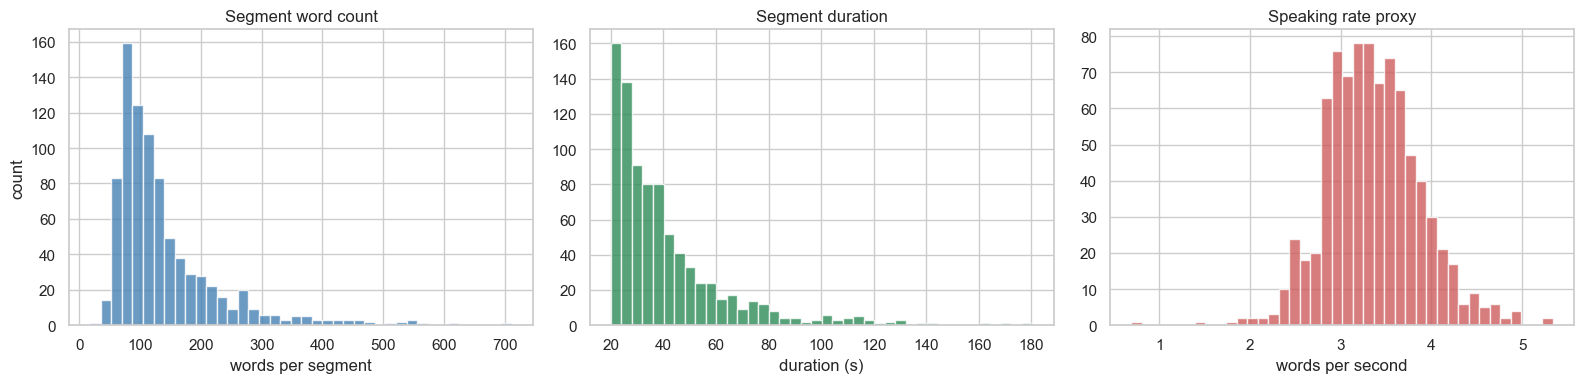

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(speech_lab['word_count'], bins=40, color='steelblue', alpha=0.8)
axes[0].set_xlabel('words per segment'); axes[0].set_ylabel('count')
axes[0].set_title('Segment word count')

axes[1].hist(speech_lab['duration'], bins=40, color='seagreen', alpha=0.8)
axes[1].set_xlabel('duration (s)')
axes[1].set_title('Segment duration')

axes[2].hist(speech_lab['words_per_sec'].dropna(), bins=40, color='indianred', alpha=0.8)
axes[2].set_xlabel('words per second')
axes[2].set_title('Speaking rate proxy')
plt.tight_layout(); plt.show()


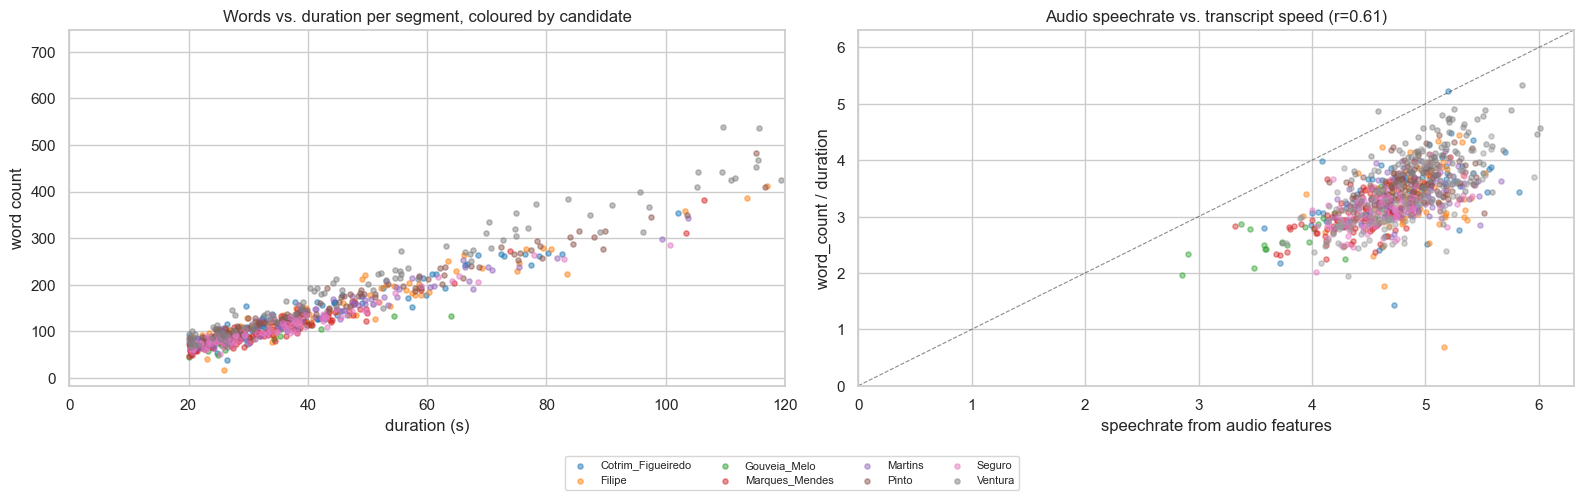

In [10]:
candidates_present = [c for c in CANDIDATES if c in speech_lab['candidate'].unique()]
palette = sns.color_palette('tab10', len(candidates_present))
color_map = dict(zip(candidates_present, palette))
color_map['interviewer'] = (0.6, 0.6, 0.6)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for cand in candidates_present:
    sub = speech_lab[speech_lab['candidate'] == cand]
    axes[0].scatter(sub['duration'], sub['word_count'],
                    s=14, alpha=0.5, label=cand, color=color_map[cand])
axes[0].set_xlabel('duration (s)')
axes[0].set_ylabel('word count')
axes[0].set_title('Words vs. duration per segment, coloured by candidate')
axes[0].set_xlim(0, 120)

rate_df = speech_lab.dropna(subset=['speechrate', 'words_per_sec'])
for cand in candidates_present + ['interviewer']:
    sub = rate_df[rate_df['candidate'] == cand]
    if len(sub) == 0:
        continue
    axes[1].scatter(sub['speechrate'], sub['words_per_sec'],
                    s=14, alpha=0.45, label=cand, color=color_map.get(cand, 'lightgray'))
if len(rate_df):
    lim_max = max(rate_df['speechrate'].max(), rate_df['words_per_sec'].max()) * 1.05
    axes[1].plot([0, lim_max], [0, lim_max], 'k--', lw=0.8, alpha=0.5)
    axes[1].set_xlim(0, lim_max)
    axes[1].set_ylim(0, lim_max)
    corr_rate = rate_df[['speechrate', 'words_per_sec']].corr().iloc[0, 1]
    axes[1].set_title(f'Audio speechrate vs. transcript speed (r={corr_rate:.2f})')
else:
    axes[1].set_title('Audio speechrate unavailable')
axes[1].set_xlabel('speechrate from audio features')
axes[1].set_ylabel('word_count / duration')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=8, ncol=4, loc='lower center')
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


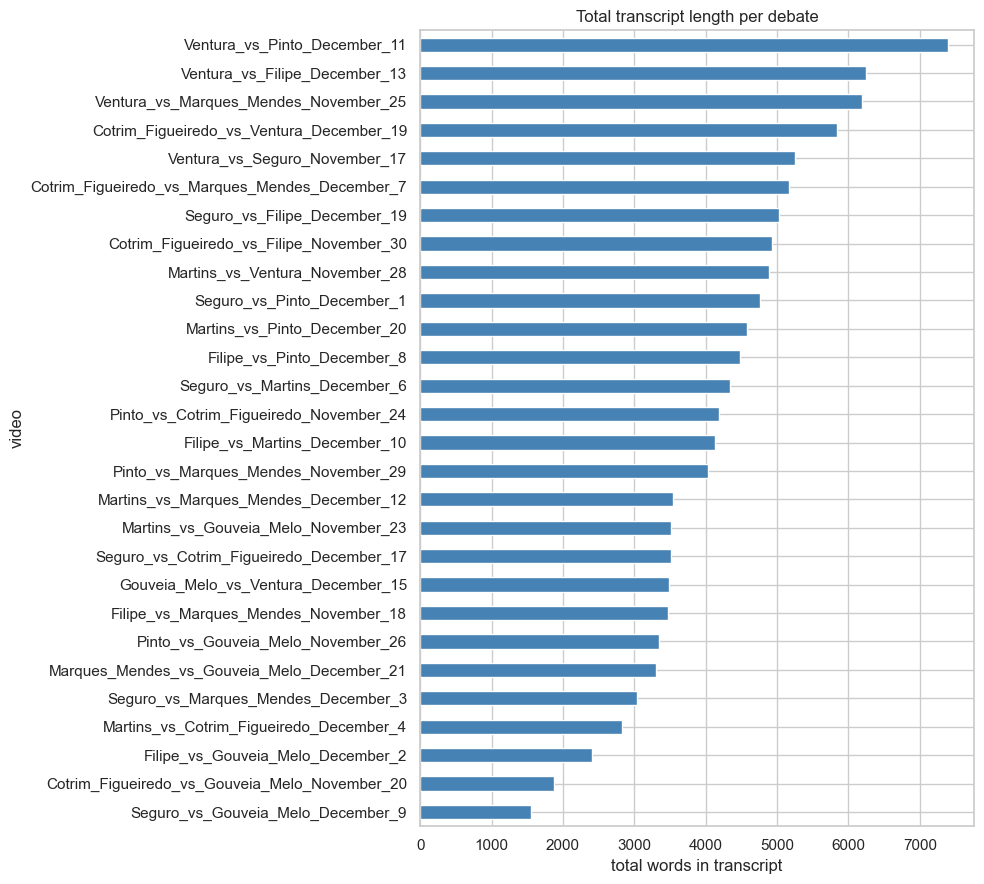

In [11]:
totals = (speech_lab.groupby('video')['word_count'].sum()
          .sort_values(ascending=True))
fig, ax = plt.subplots(figsize=(10, 9))
totals.plot(kind='barh', color='steelblue', ax=ax)
ax.set_xlabel('total words in transcript'); ax.set_title('Total transcript length per debate')
plt.tight_layout(); plt.show()

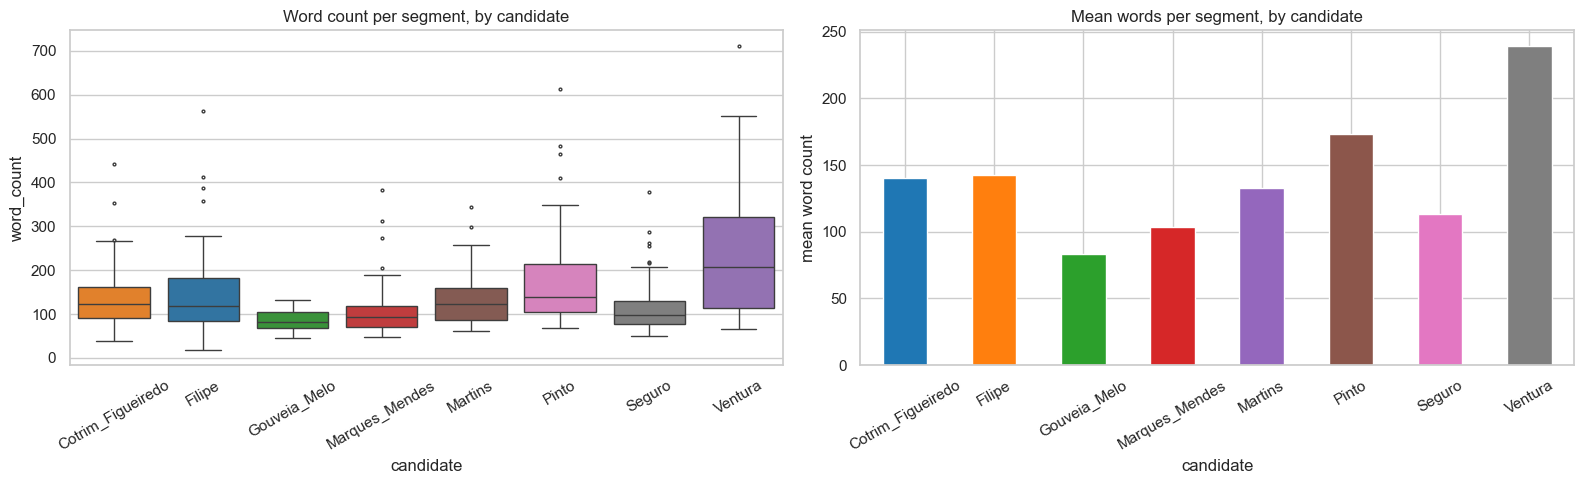

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_df = speech_lab[speech_lab['candidate'].isin(candidates_present)]
sns.boxplot(data=plot_df, x='candidate', y='word_count',
            order=candidates_present, ax=axes[0], hue='candidate',
            palette='tab10', legend=False, fliersize=2)
axes[0].set_title('Word count per segment, by candidate'); axes[0].tick_params(axis='x', rotation=30)

mean_words = (plot_df.groupby('candidate')['word_count']
              .mean().reindex(candidates_present))
mean_words.plot(kind='bar', ax=axes[1], color=[color_map[c] for c in candidates_present])
axes[1].set_title('Mean words per segment, by candidate')
axes[1].set_ylabel('mean word count'); axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 4. Language patterns: normalized words, phrases, and TF-IDF

Raw word counts are biased by how much transcript coverage each candidate has. This section uses:

- content-word frequencies normalized per 1,000 candidate tokens
- bigrams to capture phrases/themes better than isolated words
- candidate-vs-average TF-IDF scores for distinctive vocabulary

Generic debate filler words are removed so the lists are more interpretable.


In [13]:
PT_STOPWORDS = {
    'a','o','de','que','e','do','da','em','um','para','é','com','não','uma','os','no','se','na','por',
    'mais','as','dos','como','mas','foi','ao','ele','das','à','seu','sua','ou','ser','quando','muito',
    'há','nos','já','está','eu','também','só','pelo','pela','até','isso','ela','entre','era','depois',
    'sem','mesmo','aos','ter','seus','suas','numa','nem','meu','às','minha','têm','pelos','elas','havia',
    'seja','qual','será','nós','tenho','lhe','deles','essas','esses','pelas','este','fosse','dele','tu',
    'te','vos','lhes','meus','minhas','teu','tua','teus','tuas','nosso','nossa','nossos','nossas',
    'dela','delas','esta','estes','estas','aquele','aquela','aqueles','aquelas','isto','aquilo','estou',
    'estamos','estão','estive','esteve','estivemos','estiveram','tinha','tínhamos','tinham','sou',
    'somos','são','éramos','eram','fui','fomos','foram','tenha','tenhamos','tenham','aí','sim',
    'então','agora','aqui','ali','assim','bem','pouco','menos','tanto','tão','onde','porque',
    'porquê','quem','quais','quanto','quantos','sempre','nunca','talvez','vai','vou','vamos',
    'tem','sr','dr','dra','sra','não','ah','eh','né','vamos','aqui','ou','tudo','nada','algo',
    'pois','antes','sobre','sob','contra','desde','dois','duas','três','algum','alguma','outras',
    'outros','outro','outra','toda','todo','todos','todas','cada','muitos','muitas','poucos','poucas',
    'eles','elas','vocês','você','senhor','senhora','não','no','já','aqui','ali','lá','tá','tô','sei',
    'acho','sabe','olha','vê','vê','né','tipo','assim','enfim','agora','depois','hoje','ontem','amanhã',
}

FILLER_STOPWORDS = {
    'dizer', 'fazer', 'coisa', 'coisas', 'portanto', 'temos', 'quero', 'quer', 'pode', 'podem',
    'ver', 'acho', 'disse', 'dizia', 'digo', 'falar', 'falou', 'senhores', 'senhoras', 'questao',
    'questão', 'ponto', 'primeiro', 'segundo', 'seguinte', 'forma', 'parte', 'vez', 'vezes',
    'claro', 'exatamente', 'precisamente', 'repare', 'olhe', 'bom', 'boa', 'noite', 'marcos',
    'luís', 'antonio', 'antónio', 'andre', 'henrique'
}
TEXT_STOPWORDS = PT_STOPWORDS | FILLER_STOPWORDS

WORD_RE = re.compile(r"[a-záéíóúâêôãõàçü]+", re.IGNORECASE)
def tokenize(text):
    return [w for w in WORD_RE.findall(str(text).lower())
            if w not in TEXT_STOPWORDS and len(w) > 2]

corpora = {}
for cand in candidates_present:
    text = ' '.join(speech_lab.loc[speech_lab['candidate'] == cand, 'transcript'].fillna(''))
    corpora[cand] = tokenize(text)

print('Tokens per candidate (after stopwords):')
for c, toks in corpora.items():
    print(f'  {c:20s} {len(toks):8d} tokens   ({len(set(toks)):5d} unique)')

def make_ngrams(tokens, n=2):
    return [' '.join(tokens[i:i+n]) for i in range(max(0, len(tokens) - n + 1))]

bigram_corpora = {c: make_ngrams(toks, 2) for c, toks in corpora.items()}

candidate_token_stats = pd.DataFrame({
    'candidate': list(corpora.keys()),
    'tokens_after_filter': [len(corpora[c]) for c in corpora],
    'unique_tokens': [len(set(corpora[c])) for c in corpora],
}).set_index('candidate')
candidate_token_stats['type_token_ratio'] = (
    candidate_token_stats['unique_tokens'] / candidate_token_stats['tokens_after_filter'].replace(0, np.nan)
)
print('\nToken diversity after filler filtering:')
display(candidate_token_stats.round(3))


Tokens per candidate (after stopwords):
  Cotrim_Figueiredo        5053 tokens   ( 2655 unique)
  Filipe                   5514 tokens   ( 2569 unique)
  Gouveia_Melo              765 tokens   (  563 unique)
  Marques_Mendes           4344 tokens   ( 2030 unique)
  Martins                  5341 tokens   ( 2236 unique)
  Pinto                    7418 tokens   ( 2895 unique)
  Seguro                   4319 tokens   ( 1997 unique)
  Ventura                  8264 tokens   ( 3270 unique)

Token diversity after filler filtering:


,tokens_after_filter,unique_tokens,type_token_ratio
candidate,,,
Cotrim_Figueiredo,5053,2655,0.525
Filipe,5514,2569,0.466
Gouveia_Melo,765,563,0.736
Marques_Mendes,4344,2030,0.467
Martins,5341,2236,0.419
Pinto,7418,2895,0.390
Seguro,4319,1997,0.462
Ventura,8264,3270,0.396


In [14]:
TOP_N = 15

def top_per_1000(items, n=TOP_N):
    cnt = Counter(items)
    denom = max(len(items) / 1000, 1e-9)
    return [(term, count, count / denom) for term, count in cnt.most_common(n)]

top_words = {}
for c, toks in corpora.items():
    top_words[c] = [f'{w} ({rate:.1f}/1k)' for w, _, rate in top_per_1000(toks)]

freq_df = pd.DataFrame(top_words)
print(f'Top-{TOP_N} content words per candidate, normalized per 1,000 filtered tokens:')
display(freq_df)

top_bigrams = {}
for c, grams in bigram_corpora.items():
    top_bigrams[c] = [f'{w} ({rate:.1f}/1k)' for w, _, rate in top_per_1000(grams, n=10)]

bigram_df = pd.DataFrame(top_bigrams)
print('\nTop-10 content bigrams per candidate, normalized per 1,000 filtered bigrams:')
display(bigram_df)


Top-15 content words per candidate, normalized per 1,000 filtered tokens:


,Cotrim_Figueiredo,Filipe,Gouveia_Melo,Marques_Mendes,Martins,Pinto,Seguro,Ventura
0,pessoas (7.9/1k),república (15.4/1k),estado (11.8/1k),república (7.4/1k),país (12.4/1k),república (15.0/1k),país (11.3/1k),país (10.6/1k)
1,essa (6.1/1k),presidente (10.7/1k),portugueses (9.2/1k),presidente (7.4/1k),portugal (11.6/1k),país (12.8/1k),momento (6.5/1k),portugal (8.8/1k)
2,estado (5.5/1k),trabalhadores (9.6/1k),presidência (7.8/1k),governo (7.1/1k),pessoas (9.7/1k),portugal (9.4/1k),república (6.0/1k),pessoas (8.3/1k)
3,anos (5.1/1k),governo (7.8/1k),essa (7.8/1k),estado (6.0/1k),república (9.4/1k),essa (8.8/1k),governo (5.8/1k),partido (6.5/1k)
4,governo (4.4/1k),estado (5.8/1k),processo (7.8/1k),importante (5.3/1k),governo (8.2/1k),presidente (8.1/1k),economia (5.6/1k),candidato (5.8/1k)
5,esse (4.2/1k),pessoas (5.4/1k),deve (6.5/1k),tempo (4.8/1k),exemplo (6.7/1k),portugueses (7.4/1k),neste (5.1/1k),estava (5.6/1k)
6,república (4.2/1k),constituição (5.4/1k),ideias (6.5/1k),preciso (4.8/1k),trabalho (6.2/1k),anos (6.2/1k),saúde (5.1/1k),governo (5.6/1k)
7,faz (3.8/1k),creio (5.4/1k),parece (6.5/1k),pessoas (4.4/1k),preciso (5.8/1k),constituição (5.0/1k),situação (4.6/1k),lei (5.4/1k)
8,problemas (3.8/1k),direitos (5.3/1k),autor (6.5/1k),anos (4.4/1k),economia (5.1/1k),verdade (4.4/1k),estado (4.6/1k),dar (5.3/1k)
9,saúde (3.6/1k),essa (5.1/1k),mentos (6.5/1k),momento (4.4/1k),importante (5.1/1k),exemplo (4.3/1k),presidente (4.4/1k),estado (4.7/1k)



Top-10 content bigrams per candidate, normalized per 1,000 filtered bigrams:


,Cotrim_Figueiredo,Filipe,Gouveia_Melo,Marques_Mendes,Martins,Pinto,Seguro,Ventura
0,júlio júlio (2.2/1k),presidente república (7.4/1k),autorilismo marcosmente (3.9/1k),presidente república (3.0/1k),união europeia (2.8/1k),presidente república (6.9/1k),neste momento (4.2/1k),partido socialista (2.5/1k)
1,união europeia (2.0/1k),união europeia (4.0/1k),impulmanciar força (2.6/1k),neste momento (2.3/1k),presidente república (1.5/1k),cima mesa (2.6/1k),país precisa (1.9/1k),catarina martins (1.8/1k)
2,presente república (1.6/1k),direitos trabalhadores (1.6/1k),universo autor (2.6/1k),conselho estado (1.8/1k),assembleia república (1.3/1k),união europeia (2.6/1k),serviço nacional (1.6/1k),mudar constituição (1.7/1k)
3,pés pés (1.4/1k),verdade verdade (1.5/1k),autor risco (2.6/1k),combate corrupção (1.4/1k),presidenta república (1.3/1k),diz respeito (2.0/1k),presidente república (1.4/1k),lei laboral (1.6/1k)
4,presidente república (1.2/1k),pacote laboral (1.3/1k),risco mentes (2.6/1k),ministério público (1.4/1k),debate político (1.1/1k),assembleia república (1.9/1k),sistema político (1.4/1k),bloco esquerda (1.2/1k)
5,trem trem (1.2/1k),presente república (1.3/1k),angola desk (2.6/1k),catarina martins (1.4/1k),presente república (1.1/1k),projeto europeu (1.8/1k),legislação laboral (1.4/1k),dar exemplo (1.1/1k)
6,ministério público (1.0/1k),direito trabalho (0.9/1k),guerra carânio (2.6/1k),combate colupção (1.2/1k),estados unidos (1.1/1k),presente república (1.3/1k),nacional saúde (1.4/1k),ria ria (1.1/1k)
7,estados unidos (1.0/1k),acenar república (0.9/1k),vem fácil (2.6/1k),nesta matéria (0.9/1k),vida pessoas (1.1/1k),revisão constitucional (1.2/1k),partido celista (1.4/1k),imagem imagem (1.0/1k)
8,enquanto candidato (0.8/1k),greva geral (0.9/1k),fácil vem (2.6/1k),dar resposta (0.9/1k),greve geral (0.9/1k),próximas décadas (1.1/1k),situação inicial (1.2/1k),faz sentido (0.8/1k)
9,consoito estado (0.8/1k),poder político (0.9/1k),sistema político (2.6/1k),nenhuma revisão (0.9/1k),neste país (0.9/1k),neste momento (1.1/1k),tempo horas (1.2/1k),essa diferença (0.8/1k)


In [15]:
docs = [' '.join(corpora[c]) for c in candidates_present]
vect = TfidfVectorizer(min_df=1, max_features=5000)
X = vect.fit_transform(docs)
vocab = np.array(vect.get_feature_names_out())
mean_scores = np.asarray(X.mean(axis=0)).ravel()

distinctive = {}
for i, cand in enumerate(candidates_present):
    scores = X[i].toarray().ravel()
    # Candidate-vs-average score: high when a word is strong for this candidate and not generic across all candidates.
    lift = scores - mean_scores
    top_idx = lift.argsort()[::-1][:15]
    distinctive[cand] = [(vocab[j], lift[j]) for j in top_idx if lift[j] > 0]

print('Top-15 most distinctive words (candidate TF-IDF minus average TF-IDF):')
for cand, items in distinctive.items():
    words = ', '.join(w for w, _ in items)
    caution = '  [low transcript coverage]' if candidate_coverage.loc[cand, 'word_share_pct'] < 3 else ''
    print(f'  {cand:20s}  {words}{caution}')


Top-15 most distinctive words (candidate TF-IDF minus average TF-IDF):
  Cotrim_Figueiredo     júlio, trem, pessoas, irs, conseguir, qualquer, pés, problemas, certamente, fom, gêmeos, migrações, anos, faz, esse
  Filipe                creio, trabalhadores, república, presidente, direitos, crec, tap, neoliberal, constituição, facto, verdade, europeia, abril, governo, paz
  Gouveia_Melo          autor, autorilismo, mentos, governação, marcosmente, impulmanciar, angola, presidência, hospitais, ideias, universo, território, processo, internos, apliquem  [low transcript coverage]
  Marques_Mendes        combate, colupção, colrupção, ambição, joão, melhorar, prioridades, queixou, importante, estabilidade, evidentemente, ideia, matéria, deixe, preciso
  Martins               portugal, trabalho, país, pessoas, salário, direita, trabalha, preciso, exemplo, segurança, governo, horas, europa, greve, seguramente
  Pinto                 república, país, portugueses, essa, portugal, calhar, mesa, ma

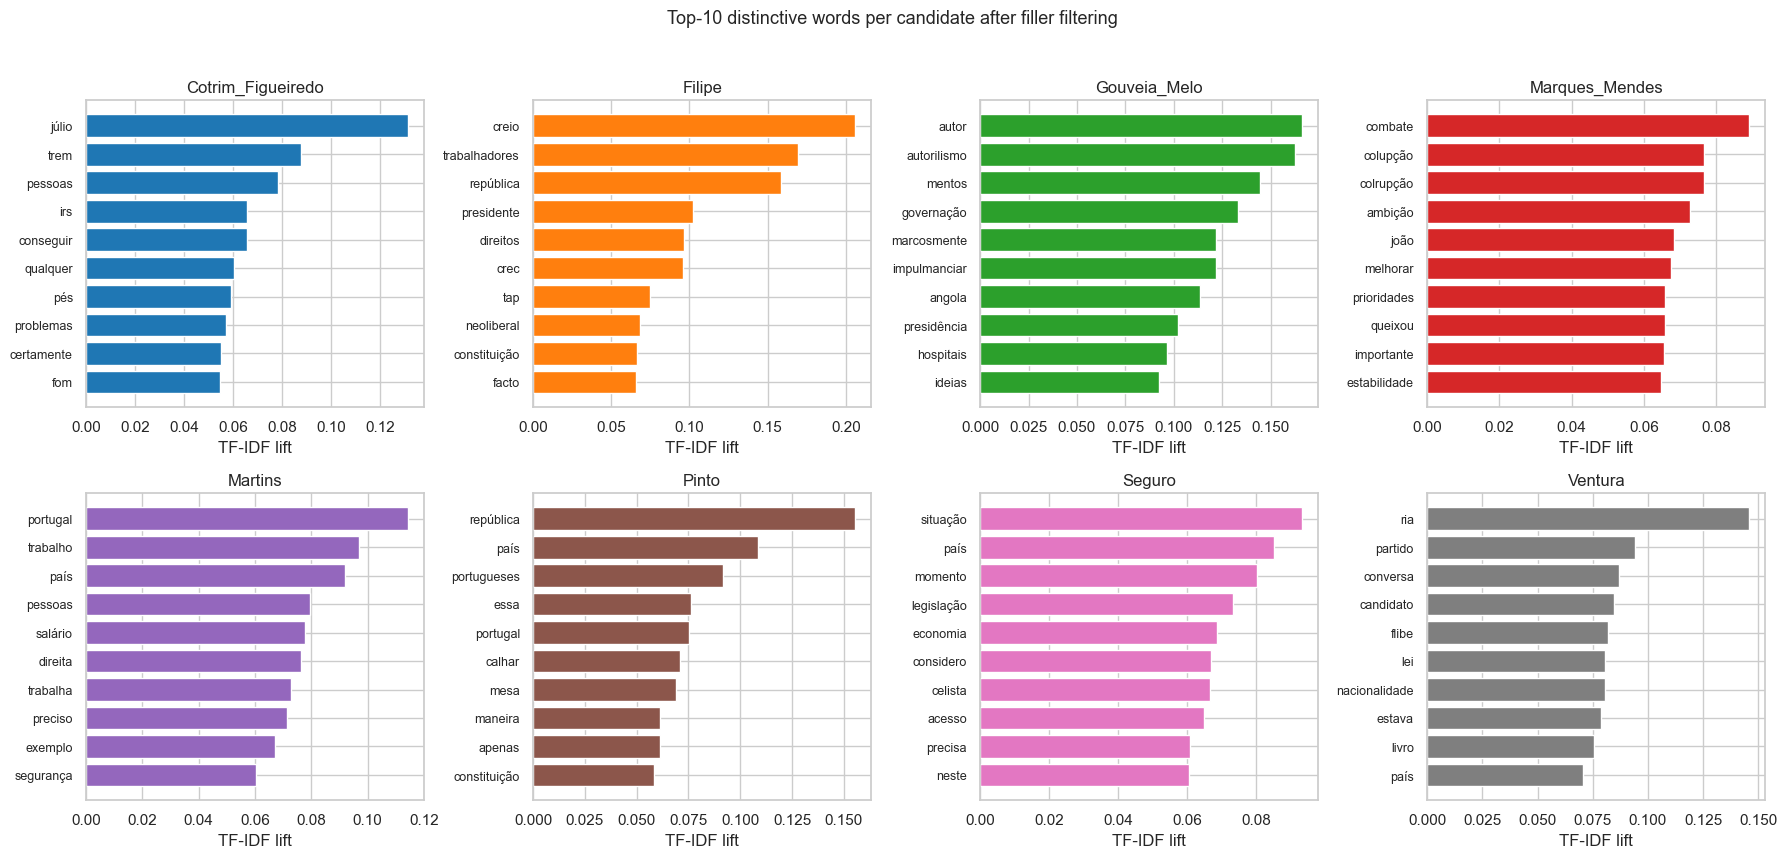

In [16]:
ncols = 4
nrows = int(np.ceil(len(candidates_present) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.2 * nrows))
axes = np.atleast_1d(axes).flatten()
for ax, cand in zip(axes, candidates_present):
    items = distinctive[cand][:10][::-1]
    if not items:
        ax.axis('off')
        continue
    words, scores = zip(*items)
    ax.barh(words, scores, color=color_map[cand])
    ax.set_title(cand)
    ax.tick_params(axis='y', labelsize=9)
    ax.set_xlabel('TF-IDF lift')
for ax in axes[len(candidates_present):]:
    ax.axis('off')
plt.suptitle('Top-10 distinctive words per candidate after filler filtering', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## 5. Polls timeline  *(required key plot #1)*

13 polls between October 2025 and January 2026, by 6 agencies. We parse dates (year inferred
by month: Oct/Nov/Dec → 2025, Jan → 2026), then plot percentages over time per candidate,
faceted by agency, and as a most-recent-snapshot bar.

In [17]:
MONTH = {'October': 10, 'November': 11, 'December': 12, 'January': 1}
def parse_poll_date(s):
    parts = s.split('_')
    month, day = parts[0], int(parts[1])
    m = MONTH[month]
    year = 2025 if m >= 10 else 2026
    return pd.Timestamp(year=year, month=m, day=day)

polls = polls.copy()
polls['date_dt'] = polls['date'].apply(parse_poll_date)
polls = polls.sort_values('date_dt').reset_index(drop=True)

cand_cols = [c for c in polls.columns if c in CANDIDATES]
polls_long = polls.melt(
    id_vars=['date', 'date_dt', 'Poll_source'],
    value_vars=cand_cols, var_name='candidate', value_name='pct',
)
polls_long['party'] = polls_long['candidate'].map(candidate_to_party)
print(f'polls_long rows: {len(polls_long)}  (expected {len(polls)} x {len(cand_cols)} = {len(polls)*len(cand_cols)})')
polls_long.head()

polls_long rows: 104  (expected 13 x 8 = 104)


,date,date_dt,Poll_source,candidate,pct,party
0,October_13,2025-10-13,Pitagorica,Gouveia_Melo,26.9,Independent
1,October_30,2025-10-30,Intercampus,Gouveia_Melo,15.4,Independent
2,November_2,2025-11-02,Aximage,Gouveia_Melo,24.4,Independent
3,November_17,2025-11-17,Pitagorica,Gouveia_Melo,21.1,Independent
4,November_20,2025-11-20,Intercampus,Gouveia_Melo,15.5,Independent


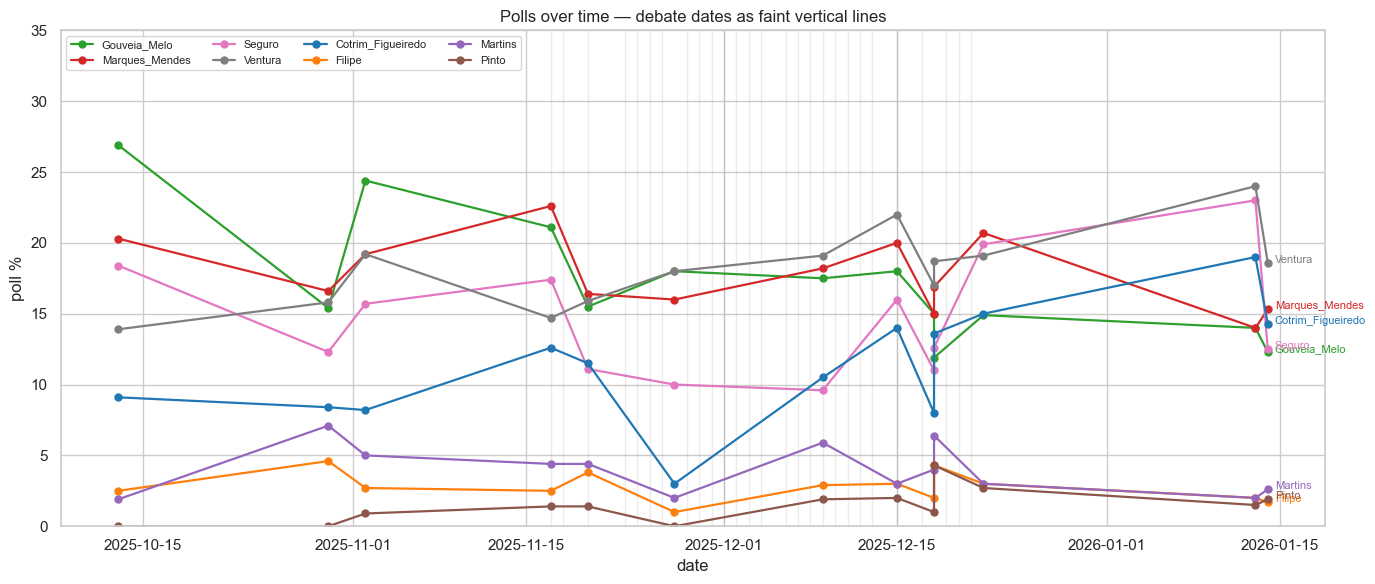

In [18]:
DEBATE_MONTH = {'November': 11, 'December': 12}
def parse_debate_date(video_name):
    for m_name, m in DEBATE_MONTH.items():
        if f'_{m_name}_' in video_name:
            day = int(video_name.split(f'_{m_name}_')[1])
            return pd.Timestamp(year=2025, month=m, day=day)
    return None

debate_dates = sorted(d for d in {parse_debate_date(v) for v in speech['video'].unique()} if d is not None)

fig, ax = plt.subplots(figsize=(14, 6))
for cand in cand_cols:
    sub = polls_long[polls_long['candidate'] == cand]
    ax.plot(sub['date_dt'], sub['pct'], marker='o', label=cand,
            color=color_map.get(cand, 'gray'), linewidth=1.6, markersize=5)
    last = sub.iloc[-1]
    ax.annotate(cand, (last['date_dt'], last['pct']),
                fontsize=8, xytext=(5, 0), textcoords='offset points',
                color=color_map.get(cand, 'gray'))

for d in debate_dates:
    ax.axvline(d, color='gray', alpha=0.15, linewidth=1)

ax.set_ylabel('poll %'); ax.set_xlabel('date')
ax.set_title('Polls over time — debate dates as faint vertical lines')
ax.set_ylim(0, max(35, polls_long['pct'].max() + 3))
ax.legend(fontsize=8, ncol=4, loc='upper left')
plt.tight_layout(); plt.show()

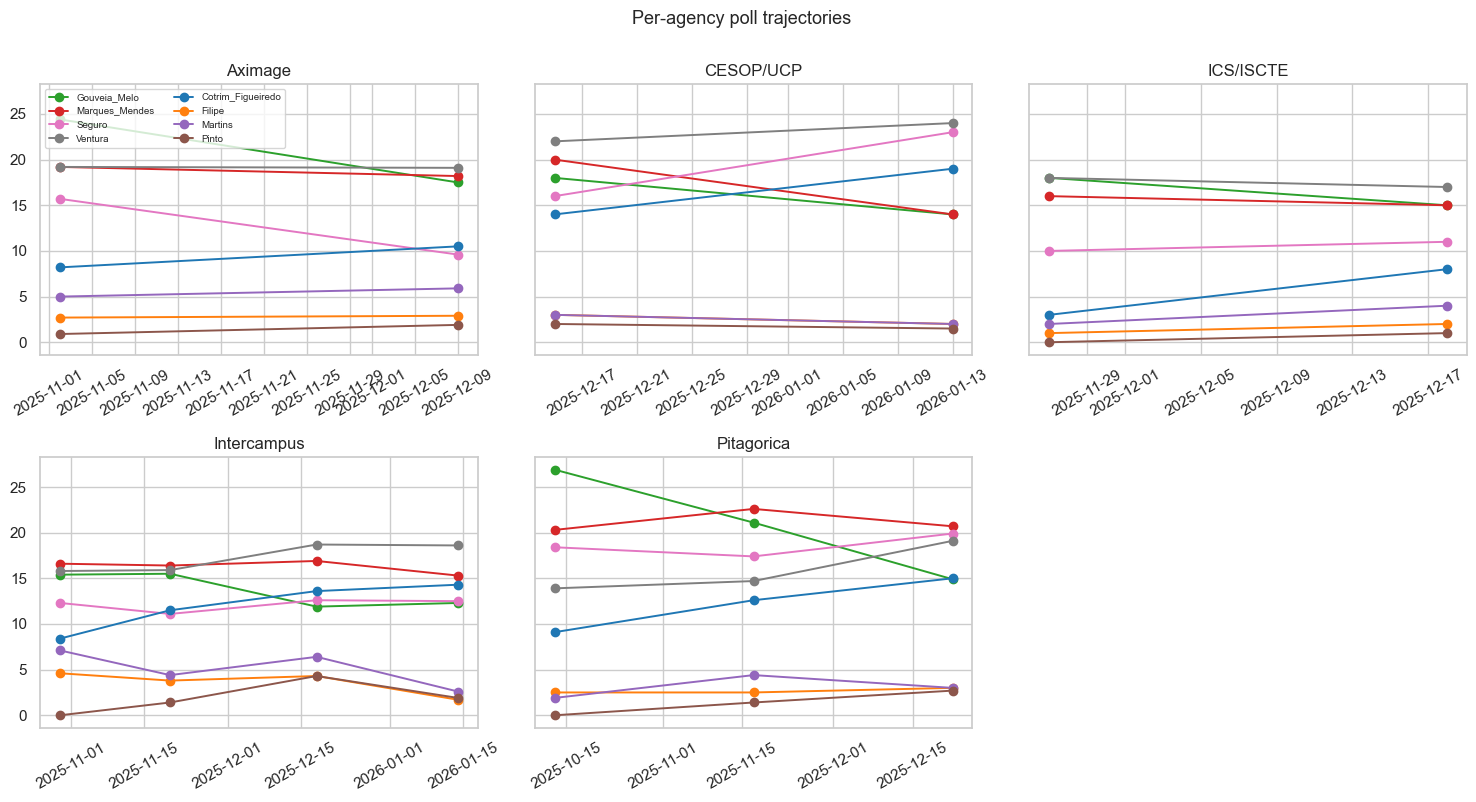

In [19]:
sources = sorted(polls['Poll_source'].unique())
ncols = 3
nrows = int(np.ceil(len(sources) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharey=True)
axes = axes.flatten()
for ax, src in zip(axes, sources):
    sub = polls_long[polls_long['Poll_source'] == src]
    for cand in cand_cols:
        s2 = sub[sub['candidate'] == cand]
        ax.plot(s2['date_dt'], s2['pct'], marker='o', label=cand,
                color=color_map.get(cand, 'gray'), linewidth=1.4)
    ax.set_title(src); ax.tick_params(axis='x', rotation=30)
for ax in axes[len(sources):]:
    ax.axis('off')
axes[0].legend(fontsize=7, ncol=2, loc='upper left')
plt.suptitle('Per-agency poll trajectories', y=1.0, fontsize=13)
plt.tight_layout(); plt.show()

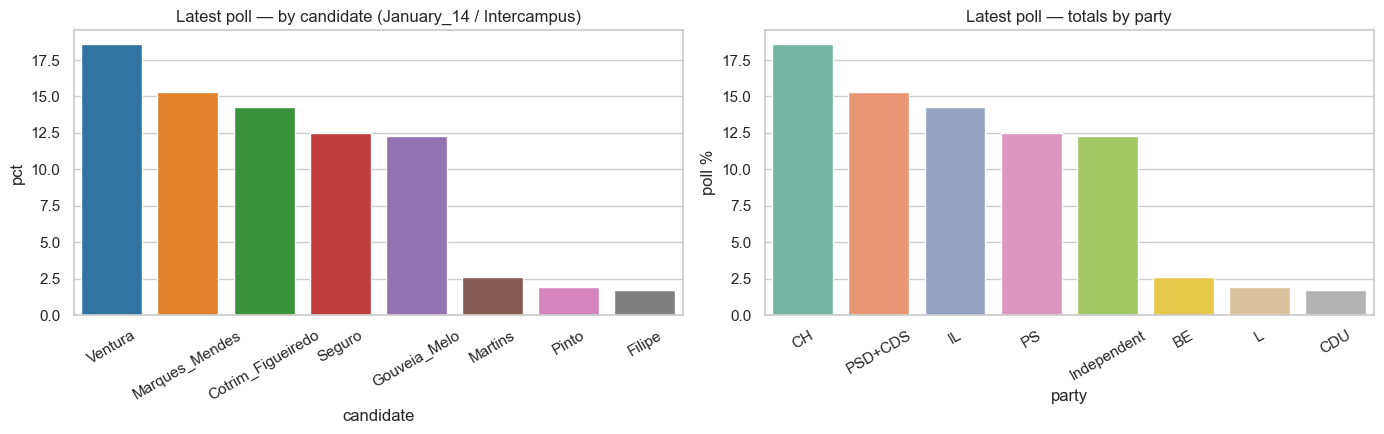

In [20]:
# Latest single poll snapshot (most recent date + source).
latest_row = polls.iloc[-1]
latest = polls_long[(polls_long['date_dt'] == latest_row['date_dt']) &
                    (polls_long['Poll_source'] == latest_row['Poll_source'])]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=latest.sort_values('pct', ascending=False),
            x='candidate', y='pct', ax=axes[0],
            hue='candidate', palette='tab10', legend=False)
axes[0].set_title(f'Latest poll — by candidate ({latest_row["date"]} / {latest_row["Poll_source"]})')
axes[0].tick_params(axis='x', rotation=30)

by_party = latest.groupby('party')['pct'].sum().sort_values(ascending=False)
sns.barplot(x=by_party.index, y=by_party.values, ax=axes[1],
            hue=by_party.index, palette='Set2', legend=False)
axes[1].set_title('Latest poll — totals by party'); axes[1].set_ylabel('poll %')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 5b. Poll movement around debate dates

For every (debate, candidate), the change in poll % between the **7 days after** the debate
and the **7 days before**. Cells where neither window has a poll show as NaN.
Polls are sparse (13 readings across 5 agencies), so this is best read as a *signal* rather
than a precise measurement — but it directly answers "did this debate move the polls?".


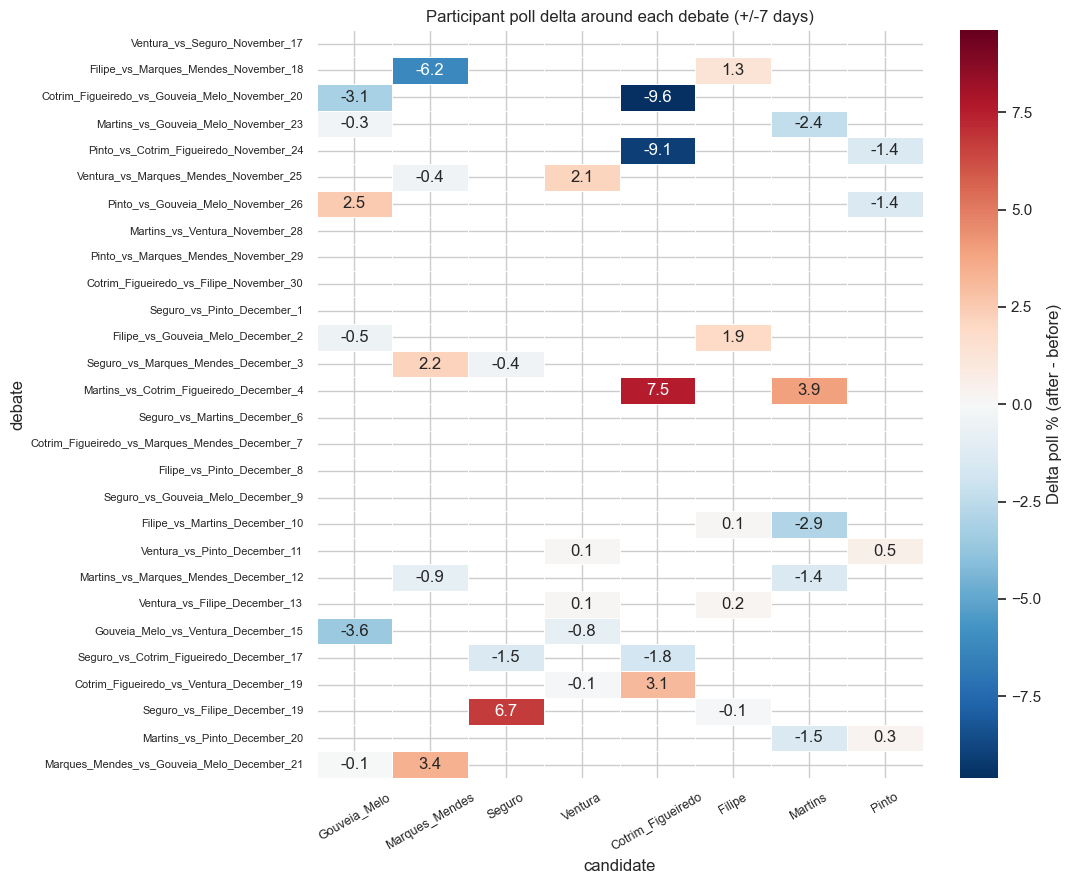

Participant coverage: 38 of 56 debate-participant cells had polls in BOTH windows.
This is an association check only: polls are sparse, agencies differ, and debates are not isolated events.

Mean participant poll delta by candidate:


,mean_delta,median_delta,n
candidate,,,
Seguro,1.60,-0.40,3
Filipe,0.68,0.20,5
Ventura,0.28,0.13,5
Marques_Mendes,-0.38,-0.40,5
Pinto,-0.50,-0.57,4
Gouveia_Melo,-0.84,-0.40,6
Martins,-0.86,-1.47,5
Cotrim_Figueiredo,-1.96,-1.80,5



Largest absolute participant moves (|Delta| >= 1 pp):


,video,candidate,date_dt,delta,is_debate_participant,n_before,n_after
12,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,Cotrim_Figueiredo,2025-11-20,-9.60,True,1,1
124,Pinto_vs_Cotrim_Figueiredo_November_24,Cotrim_Figueiredo,2025-11-24,-9.05,True,2,1
84,Martins_vs_Cotrim_Figueiredo_December_4,Cotrim_Figueiredo,2025-12-04,7.50,True,1,1
154,Seguro_vs_Filipe_December_19,Seguro,2025-12-19,6.70,True,3,1
41,Filipe_vs_Marques_Mendes_November_18,Marques_Mendes,2025-11-18,-6.20,True,1,1
86,Martins_vs_Cotrim_Figueiredo_December_4,Martins,2025-12-04,3.90,True,1,1
64,Gouveia_Melo_vs_Ventura_December_15,Gouveia_Melo,2025-12-15,-3.57,True,1,3
73,Marques_Mendes_vs_Gouveia_Melo_December_21,Marques_Mendes,2025-12-21,3.40,True,3,1
28,Cotrim_Figueiredo_vs_Ventura_December_19,Cotrim_Figueiredo,2025-12-19,3.13,True,3,1
8,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,Gouveia_Melo,2025-11-20,-3.10,True,1,1


In [21]:
WINDOW = pd.Timedelta(days=7)

video_to_date = {v: parse_debate_date(v) for v in speech_lab['video'].unique()}
video_to_date = {v: d for v, d in video_to_date.items() if d is not None}

rows = []
for video, ddate in video_to_date.items():
    debate_candidates = set(extract_candidates(video))
    for cand in cand_cols:
        sub = polls_long[polls_long['candidate'] == cand]
        before = sub[(sub['date_dt'] >= ddate - WINDOW) & (sub['date_dt'] < ddate)]['pct']
        after = sub[(sub['date_dt'] > ddate) & (sub['date_dt'] <= ddate + WINDOW)]['pct']
        delta = (after.mean() - before.mean()) if (len(before) and len(after)) else np.nan
        rows.append({
            'video': video,
            'candidate': cand,
            'date_dt': ddate,
            'delta': delta,
            'is_debate_participant': cand in debate_candidates,
            'n_before': len(before),
            'n_after': len(after),
        })
delta_df = pd.DataFrame(rows)

participant_delta = delta_df[delta_df['is_debate_participant']]
participant_pivot = participant_delta.pivot(index='video', columns='candidate', values='delta')
participant_pivot = participant_pivot.loc[sorted(participant_pivot.index, key=lambda v: video_to_date[v])]
participant_pivot = participant_pivot[[c for c in cand_cols if c in participant_pivot.columns]]

finite_vals = np.abs(participant_pivot.values[np.isfinite(participant_pivot.values)])
vmax = float(finite_vals.max()) if len(finite_vals) else 1.0
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(participant_pivot, annot=True, fmt='.1f', cmap='RdBu_r',
            center=0, vmin=-vmax, vmax=vmax,
            linewidths=0.4, cbar_kws={'label': 'Delta poll % (after - before)'},
            ax=ax)
ax.set_title('Participant poll delta around each debate (+/-7 days)')
ax.set_xlabel('candidate')
ax.set_ylabel('debate')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

print(f'Participant coverage: {participant_delta["delta"].notna().sum()} of {len(participant_delta)} debate-participant cells had polls in BOTH windows.')
print('This is an association check only: polls are sparse, agencies differ, and debates are not isolated events.')

candidate_delta_summary = (participant_delta.dropna(subset=['delta'])
    .groupby('candidate')
    .agg(mean_delta=('delta', 'mean'), median_delta=('delta', 'median'), n=('delta', 'count'))
    .sort_values('mean_delta', ascending=False))
print('\nMean participant poll delta by candidate:')
display(candidate_delta_summary.round(2))

print('\nLargest absolute participant moves (|Delta| >= 1 pp):')
notable = participant_delta.dropna(subset=['delta']).copy()
notable['abs'] = notable['delta'].abs()
display(notable[notable['abs'] >= 1.0]
        .sort_values('abs', ascending=False)
        .drop(columns='abs')
        .head(15)
        .round({'delta': 2}))


## 5c. Inter-pollster disagreement

For each polling event, find the readings from *other* agencies within ±5 days for the
same candidate, then compute the std across that small set. Average per candidate.
A high value means agencies disagreed about that candidate's level.


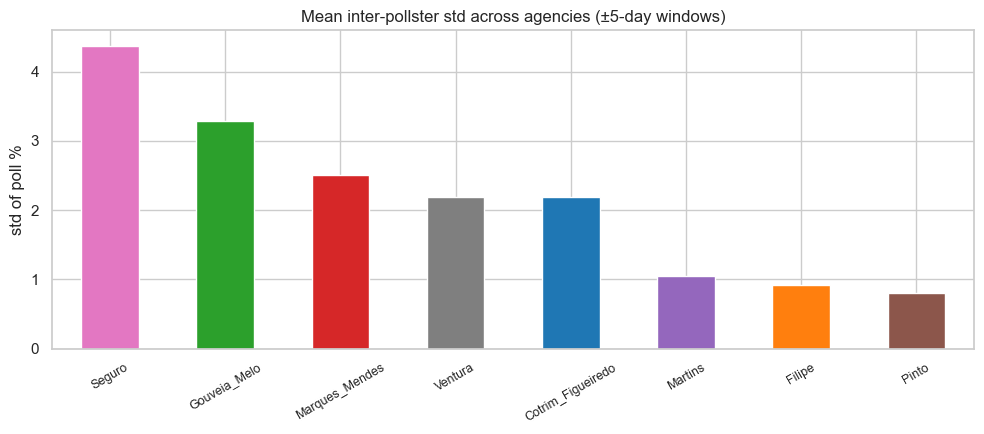

Mean disagreement per candidate (pp):
Seguro               4.38
Gouveia_Melo         3.28
Marques_Mendes       2.51
Ventura              2.20
Cotrim_Figueiredo    2.19
Martins              1.05
Filipe               0.91
Pinto                0.80


In [22]:
WINDOW_DA = pd.Timedelta(days=5)

per_candidate_dis = {}
for cand in cand_cols:
    sub = polls_long[polls_long['candidate'] == cand].sort_values('date_dt')
    stds = []
    for _, row in sub.iterrows():
        peers = sub[(sub['date_dt'] >= row['date_dt'] - WINDOW_DA) &
                    (sub['date_dt'] <= row['date_dt'] + WINDOW_DA) &
                    (sub['Poll_source'] != row['Poll_source'])]
        if len(peers) >= 1:
            vals = np.concatenate([[row['pct']], peers['pct'].values])
            stds.append(float(np.std(vals, ddof=1)))
    if stds:
        per_candidate_dis[cand] = float(np.mean(stds))

dis_series = (pd.Series(per_candidate_dis)
              .reindex(cand_cols)
              .dropna()
              .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
dis_series.plot(kind='bar', ax=ax,
                color=[color_map.get(c, 'gray') for c in dis_series.index])
ax.set_title('Mean inter-pollster std across agencies (±5-day windows)')
ax.set_ylabel('std of poll %')
ax.tick_params(axis='x', rotation=30, labelsize=9)
plt.tight_layout(); plt.show()

print('Mean disagreement per candidate (pp):')
print(dis_series.round(2).to_string())


## 6. Pairwise transcript-embedding similarity  *(required key plot #3)*

Mean-pool the 4096-dim transcript embedding per video (28 means) and per candidate (8 means),
then compute cosine similarity matrices. Centred colour scales make the off-diagonal structure
visible against the high baseline (all debates share the same election context).

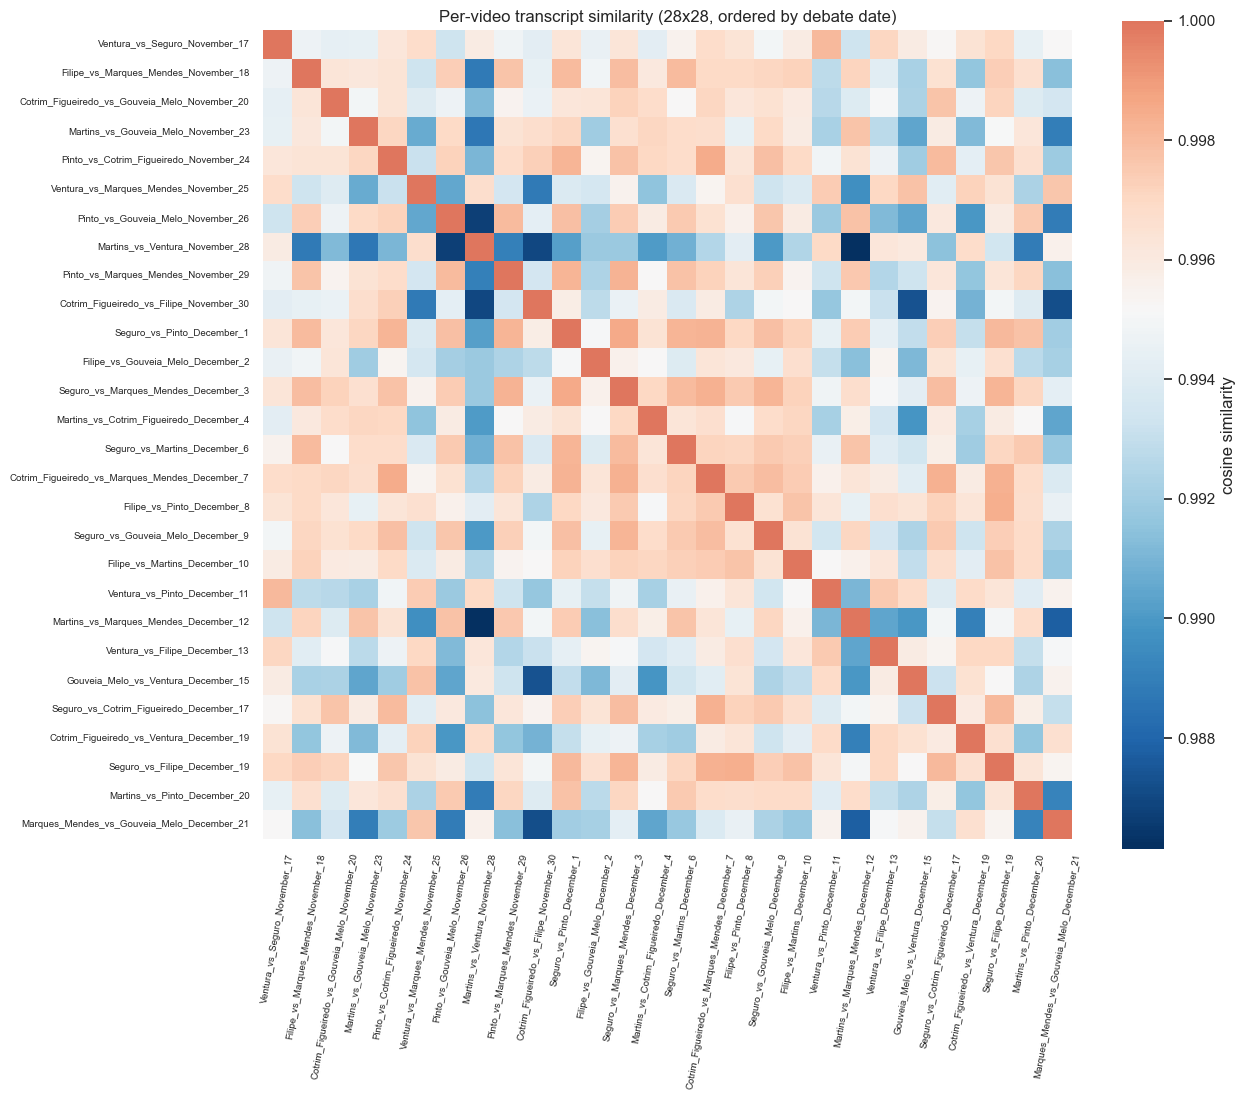

Symmetric: True; diag mean: 1.000


In [23]:
# Per-video mean embedding (28 x 4096) and 28x28 similarity.
video_embed = {}
for v, group in speech_lab.groupby('video'):
    video_embed[v] = np.stack(group['text_embedding'].values).mean(axis=0)

videos_sorted = sorted(video_embed.keys(),
                       key=lambda v: parse_debate_date(v) or pd.Timestamp.min)
video_mat = np.stack([video_embed[v] for v in videos_sorted])
sim_video = cosine_similarity(video_mat)

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(sim_video, xticklabels=videos_sorted, yticklabels=videos_sorted,
            cmap='RdBu_r', center=float(sim_video.mean()),
            square=True, ax=ax, cbar_kws={'label': 'cosine similarity'})
ax.set_title(f'Per-video transcript similarity ({len(videos_sorted)}x{len(videos_sorted)}, ordered by debate date)')
ax.tick_params(axis='x', rotation=80, labelsize=7)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout(); plt.show()

print(f'Symmetric: {np.allclose(sim_video, sim_video.T)}; diag mean: {np.diag(sim_video).mean():.3f}')

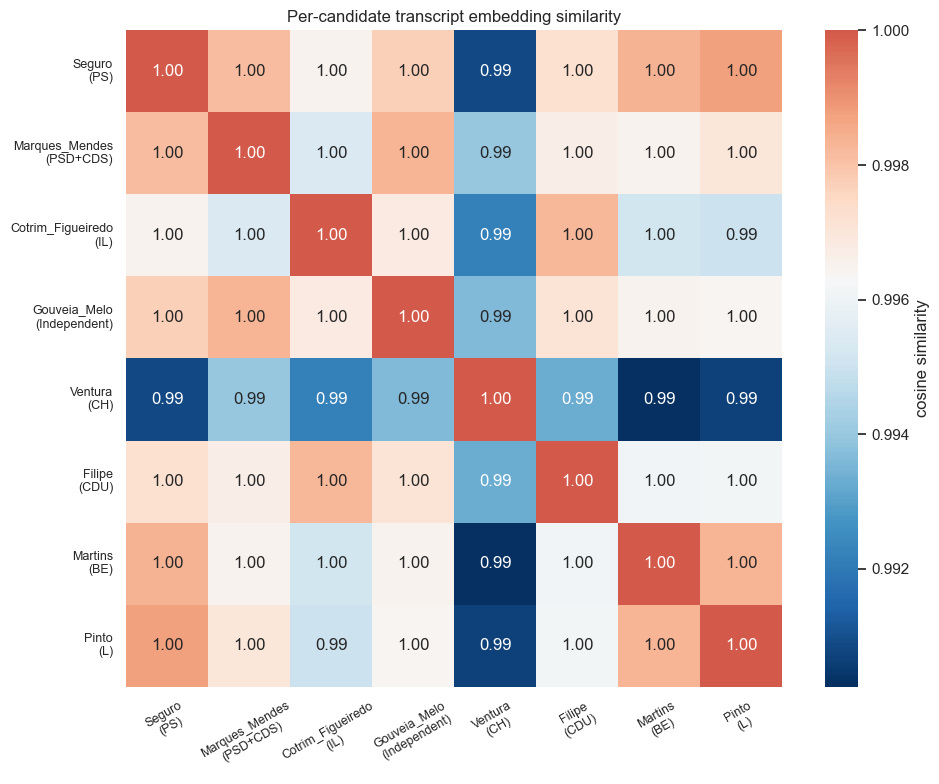

Most similar candidate pairs by transcript embeddings:


,candidate_a,candidate_b,party_a,party_b,embedding_similarity
6,Seguro,Pinto,PS,L,0.999
5,Seguro,Martins,PS,BE,0.998
27,Martins,Pinto,BE,L,0.998
8,Marques_Mendes,Gouveia_Melo,PSD+CDS,Independent,0.998
15,Cotrim_Figueiredo,Filipe,IL,CDU,0.998
0,Seguro,Marques_Mendes,PS,PSD+CDS,0.998
2,Seguro,Gouveia_Melo,PS,Independent,0.998
4,Seguro,Filipe,PS,CDU,0.997


Least similar candidate pairs by transcript embeddings:


,candidate_a,candidate_b,party_a,party_b,embedding_similarity
23,Ventura,Martins,CH,BE,0.990
24,Ventura,Pinto,CH,L,0.991
3,Seguro,Ventura,PS,CH,0.991
14,Cotrim_Figueiredo,Ventura,IL,CH,0.992
22,Ventura,Filipe,CH,CDU,0.993
18,Gouveia_Melo,Ventura,Independent,CH,0.994
9,Marques_Mendes,Ventura,PSD+CDS,CH,0.994
17,Cotrim_Figueiredo,Pinto,IL,L,0.995


In [24]:
PARTY_ORDER = ['PS', 'PSD+CDS', 'IL', 'Independent', 'CH', 'CDU', 'BE', 'L']
cand_order = sorted(candidates_present,
                    key=lambda c: PARTY_ORDER.index(candidate_to_party.get(c, 'Independent')))

cand_embed = {}
for cand in cand_order:
    sub = speech_lab[speech_lab['candidate'] == cand]
    cand_embed[cand] = np.stack(sub['text_embedding'].values).mean(axis=0)
cand_mat = np.stack([cand_embed[c] for c in cand_order])
sim_cand = cosine_similarity(cand_mat)

labels_with_party = [f'{c}\n({candidate_to_party[c]})' for c in cand_order]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_cand, xticklabels=labels_with_party, yticklabels=labels_with_party,
            cmap='RdBu_r', center=float(sim_cand.mean()),
            annot=True, fmt='.2f', square=True, ax=ax,
            cbar_kws={'label': 'cosine similarity'})
ax.set_title('Per-candidate transcript embedding similarity')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

pair_rows = []
for i, j in combinations(range(len(cand_order)), 2):
    pair_rows.append({
        'candidate_a': cand_order[i],
        'candidate_b': cand_order[j],
        'party_a': candidate_to_party[cand_order[i]],
        'party_b': candidate_to_party[cand_order[j]],
        'embedding_similarity': sim_cand[i, j],
    })
embedding_pairs = pd.DataFrame(pair_rows)
print('Most similar candidate pairs by transcript embeddings:')
display(embedding_pairs.sort_values('embedding_similarity', ascending=False).head(8).round(3))
print('Least similar candidate pairs by transcript embeddings:')
display(embedding_pairs.sort_values('embedding_similarity', ascending=True).head(8).round(3))


**Reading the heatmaps.** A reddish off-diagonal cell means two candidates' transcript embeddings are more similar than the average pair. The baseline is high because every debate belongs to the same election context, so the colour scale is centred on the matrix mean rather than 0. Use the pair tables as the concrete finding and the heatmap as the overview.


## 6b. Lexical similarity cross-check

Embedding similarity can capture broad semantic overlap. A TF-IDF similarity matrix checks whether the same conclusion also appears in the surface vocabulary.


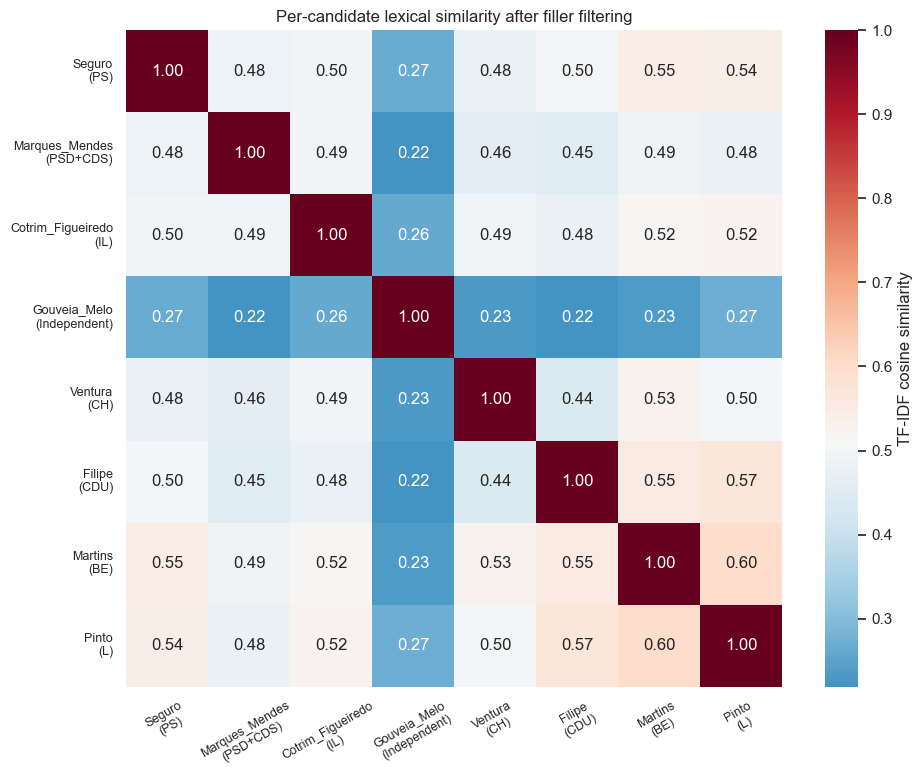

Pairs where semantic similarity is much higher than lexical overlap:


,candidate_a,candidate_b,embedding_similarity,lexical_similarity,difference_embed_minus_lex
8,Marques_Mendes,Gouveia_Melo,0.998,0.219,0.779
19,Gouveia_Melo,Filipe,0.997,0.222,0.775
20,Gouveia_Melo,Martins,0.997,0.235,0.762
18,Gouveia_Melo,Ventura,0.994,0.232,0.762
13,Cotrim_Figueiredo,Gouveia_Melo,0.997,0.261,0.736
2,Seguro,Gouveia_Melo,0.998,0.267,0.731
21,Gouveia_Melo,Pinto,0.996,0.274,0.723
22,Ventura,Filipe,0.993,0.441,0.552


In [25]:
lex_docs = [' '.join(corpora[c]) for c in cand_order]
lex_vect = TfidfVectorizer(min_df=1, max_features=5000)
lex_X = lex_vect.fit_transform(lex_docs)
sim_lex = cosine_similarity(lex_X)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_lex, xticklabels=labels_with_party, yticklabels=labels_with_party,
            cmap='RdBu_r', center=float(sim_lex.mean()),
            annot=True, fmt='.2f', square=True, ax=ax,
            cbar_kws={'label': 'TF-IDF cosine similarity'})
ax.set_title('Per-candidate lexical similarity after filler filtering')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

lex_pairs = []
for i, j in combinations(range(len(cand_order)), 2):
    lex_pairs.append({
        'candidate_a': cand_order[i],
        'candidate_b': cand_order[j],
        'embedding_similarity': sim_cand[i, j],
        'lexical_similarity': sim_lex[i, j],
        'difference_embed_minus_lex': sim_cand[i, j] - sim_lex[i, j],
    })
lex_pairs = pd.DataFrame(lex_pairs)
print('Pairs where semantic similarity is much higher than lexical overlap:')
display(lex_pairs.sort_values('difference_embed_minus_lex', ascending=False).head(8).round(3))


## 7. Transcript embedding projection (PCA + t-SNE)

Companion view to the similarity matrix — local neighbourhoods of segments in the 4096-dim
embedding space. Useful for spotting whether segments cluster by candidate (their voice/topic
fingerprint) or by debate (the topic of the day).

Transcript embedding matrix: (843, 4096)
PCA explained variance: PC1=14.6%  PC2=12.3%


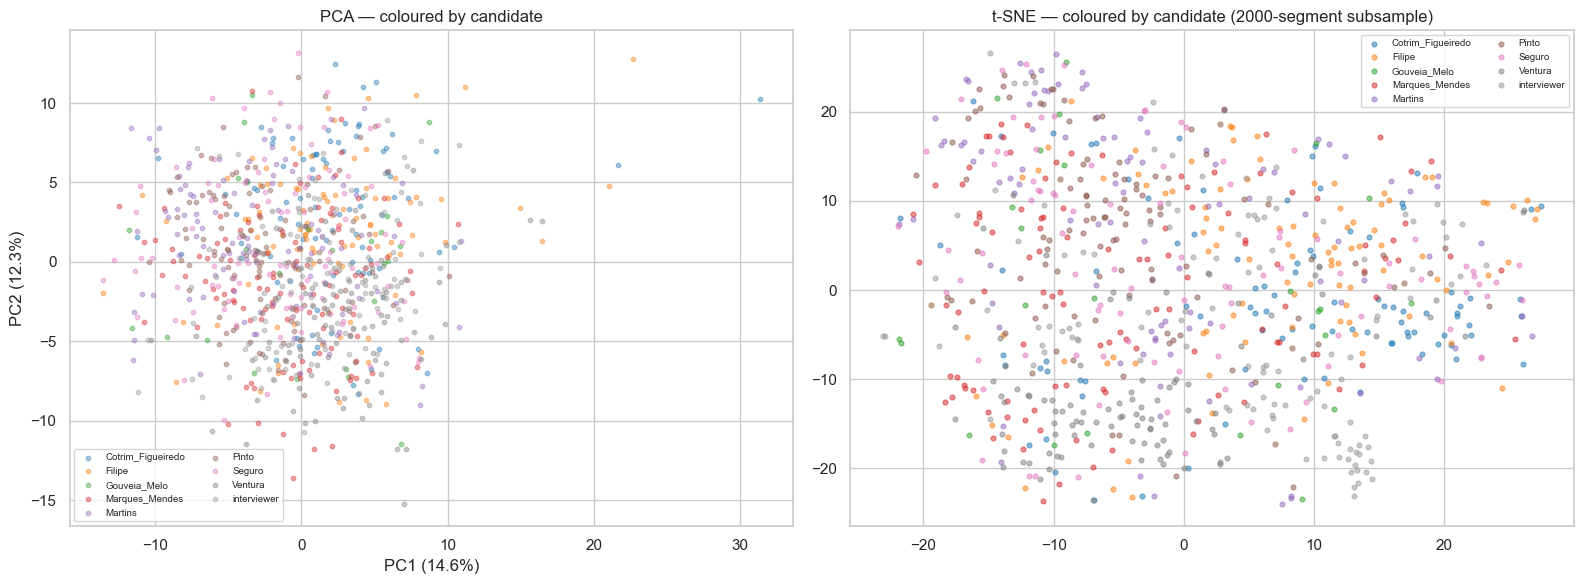

In [26]:
emb_full = np.stack(speech_lab['text_embedding'].values)
print(f'Transcript embedding matrix: {emb_full.shape}')

pca = PCA(n_components=2)
emb_pca = pca.fit_transform(emb_full)
print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  '
      f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%')

rng = np.random.RandomState(42)
sub_idx = rng.choice(len(emb_full), size=min(2000, len(emb_full)), replace=False)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
emb_tsne = tsne.fit_transform(emb_full[sub_idx])

cands_arr = speech_lab['candidate'].fillna('unknown').values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_labels = candidates_present + ['interviewer']
for cand in plot_labels:
    mask = cands_arr == cand
    if not mask.any():
        continue
    axes[0].scatter(emb_pca[mask, 0], emb_pca[mask, 1], s=10, alpha=0.4,
                    label=cand, color=color_map.get(cand, 'lightgray'))
axes[0].set_title('PCA — coloured by candidate')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=7, ncol=2)

cands_sub = cands_arr[sub_idx]
for cand in plot_labels:
    mask = cands_sub == cand
    if not mask.any():
        continue
    axes[1].scatter(emb_tsne[mask, 0], emb_tsne[mask, 1], s=12, alpha=0.5,
                    label=cand, color=color_map.get(cand, 'lightgray'))
axes[1].set_title('t-SNE — coloured by candidate (2000-segment subsample)')
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

## 7b. Topic clustering of transcript embeddings

KMeans is run on L2-normalized 4096-dim transcript embeddings. The notebook tests several `k` values by silhouette score, chooses the best one, then prints top terms and nearest transcript excerpts so the topics can be named in the report.


In [27]:
emb_full = np.stack(speech_lab['text_embedding'].values)
emb_norm = normalize(emb_full)

K_RANGE = range(5, 11)
topic_trials = []
for k in K_RANGE:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(emb_norm)
    sil = silhouette_score(emb_norm, labels, metric='cosine')
    topic_trials.append({'k': k, 'silhouette': sil, 'model': model, 'labels': labels})

topic_score_df = pd.DataFrame([{k: v for k, v in row.items() if k not in {'model', 'labels'}} for row in topic_trials])
print('Topic-cluster silhouette by k:')
display(topic_score_df.round(3))

best_topic = max(topic_trials, key=lambda row: row['silhouette'])
K_TOPICS = int(best_topic['k'])
km_topic = best_topic['model']
speech_lab['topic'] = best_topic['labels']

print(f'Chosen K_TOPICS={K_TOPICS} with cosine silhouette={best_topic["silhouette"]:.3f}')
print('Cluster sizes:')
print(speech_lab['topic'].value_counts().sort_index().to_string())

topic_top_terms = {}
for k in range(K_TOPICS):
    toks = []
    for text in speech_lab.loc[speech_lab['topic'] == k, 'transcript'].fillna(''):
        toks.extend(tokenize(text))
    topic_top_terms[k] = [w for w, _ in Counter(toks).most_common(5)]

topic_labels = {k: f'T{k}: ' + ', '.join(topic_top_terms[k][:3]) for k in range(K_TOPICS)}
topic_summary = pd.DataFrame({
    'topic': list(range(K_TOPICS)),
    'label': [topic_labels[k] for k in range(K_TOPICS)],
    'segments': [int((speech_lab['topic'] == k).sum()) for k in range(K_TOPICS)],
    'top_terms': [', '.join(topic_top_terms[k]) for k in range(K_TOPICS)],
})
print('\nAutomatic topic labels from top filtered words:')
display(topic_summary)

print('\n=== Topic prototypes: 3 segments nearest each centroid ===')
center_norm = normalize(km_topic.cluster_centers_)
for k in range(K_TOPICS):
    mask = (speech_lab['topic'] == k).values
    if not mask.any():
        continue
    sims = cosine_similarity(emb_norm[mask], center_norm[[k]]).ravel()
    nearest_local_idx = np.argsort(-sims)[:3]
    sub_rows = speech_lab[mask].iloc[nearest_local_idx]
    print(f'\n--- {topic_labels[k]}  ({mask.sum()} segments) ---')
    for _, r in sub_rows.iterrows():
        text = (r['transcript'] or '').replace('\n', ' ').strip()
        snip = text[:220]
        cand = r['candidate'] if pd.notna(r['candidate']) else '?'
        print(f'  [{cand}] {snip}{"..." if len(text) > 220 else ""}')


Topic-cluster silhouette by k:


,k,silhouette
0,5,0.087
1,6,0.078
2,7,0.088
3,8,0.068
4,9,0.078
5,10,0.083


Chosen K_TOPICS=7 with cosine silhouette=0.088
Cluster sizes:
topic
0    183
1    113
2    126
3    156
4    116
5    142
6      7

Automatic topic labels from top filtered words:


,topic,label,segments,top_terms
0,0,"T0: república, presidente, país",183,"república, presidente, país, governo, essa"
1,1,"T1: presidente, governo, república",113,"presidente, governo, república, estado, portugal"
2,2,"T2: país, economia, portugal",126,"país, economia, portugal, pessoas, saúde"
3,3,"T3: pessoas, república, governo",156,"pessoas, república, governo, trabalhadores, país"
4,4,"T4: país, portugal, pessoas",116,"país, portugal, pessoas, partido, dar"
5,5,"T5: república, tempo, presidente",142,"república, tempo, presidente, governo, estado"
6,6,"T6: ria, mim, deu",7,"ria, mim, deu, cidadão, comum"



=== Topic prototypes: 3 segments nearest each centroid ===

--- T0: república, presidente, país  (183 segments) ---
  [Pinto] E há uma grande ameaça à nossa própria República aliás, há um outro qualidade presidencial que diz no próprio, da casa da República, na Cêma da República, que quer acabar com a mesma. Essa ameaça é clara, mas ela, na ver...
  [Marques_Mendes] E a coisa mais hipócrita que há é uma pessoa pedir reformas e depois no dia 15, quando surgem reformas, dizem que não as reformas. Segundo o ponto, o que eu considero nesta área é que em matéria laboral é essencial um ac...
  [Pinto] E depois, a revolução desse lado? Acho que tem faltado em alguns aspectos, mas há uma espécie que é fundamental, precisamente, de indivíduos dessa sondagem, que diz respeito à interferência e a intervenção de um futuro p...

--- T1: presidente, governo, república  (113 segments) ---
  [Ventura] Concorda como hoje não foi o André Venter que foi derrotado, foi o país que foi derrotado. É o povo 

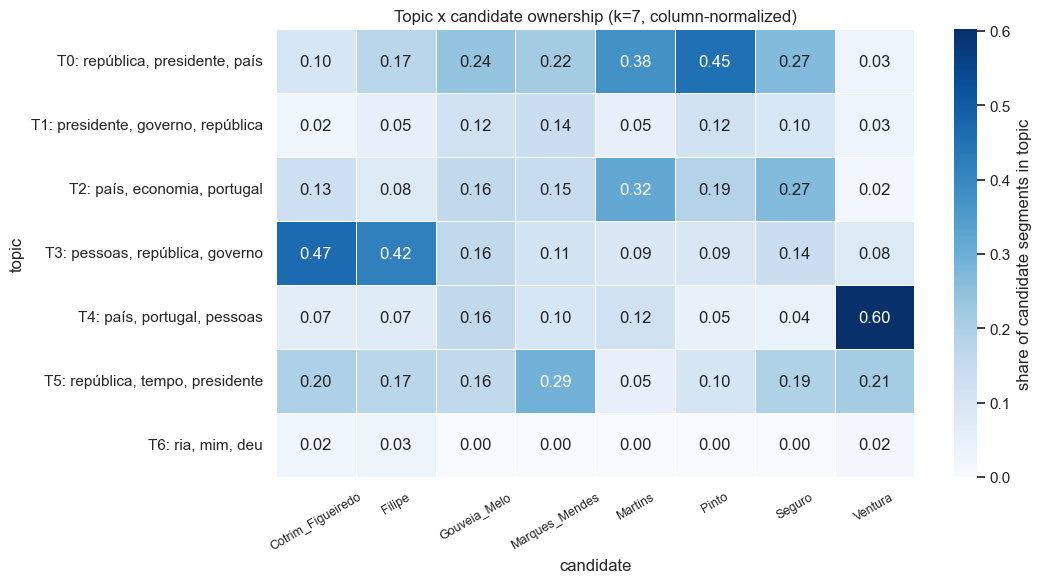

In [28]:
# Topic x candidate ownership.
# Columns are normalized so each candidate's column sums to 1: what share of this candidate's segments fell in topic T.
mask = speech_lab['candidate'].isin(candidates_present)
topic_cand = (speech_lab[mask]
              .groupby(['topic', 'candidate']).size()
              .unstack(fill_value=0)
              .reindex(index=range(K_TOPICS), columns=candidates_present, fill_value=0))
topic_cand_norm = topic_cand.div(topic_cand.sum(axis=0).replace(0, np.nan), axis=1)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(topic_cand_norm, annot=True, fmt='.2f', cmap='Blues',
            cbar_kws={'label': 'share of candidate segments in topic'},
            linewidths=0.4, ax=ax)
ax.set_title(f'Topic x candidate ownership (k={K_TOPICS}, column-normalized)')
ax.set_xlabel('candidate')
ax.set_ylabel('topic')
ax.set_yticklabels([topic_labels[k] for k in topic_cand_norm.index], rotation=0)
ax.tick_params(axis='x', rotation=30, labelsize=9)
plt.tight_layout()
plt.show()


## 7c. Topic share vs. post-debate poll movement

Joins §5b (Δ poll per debate × candidate) with §7b (topic share per debate × candidate).
For each topic, Pearson correlation of "share of segments in this topic" with
"post-debate Δ in poll %". Positive → talking more about that topic *associates*
with poll gains in that debate's aftermath. Sample sizes are small (≤ 56 cells),
so this is suggestive, not causal.


Correlation between topic share and post-debate participant poll delta:


,topic,topic_label,n,pearson_r,mean_share
2,2,"T2: país, economia, portugal",25,0.065,0.256
5,5,"T5: república, tempo, presidente",29,0.064,0.210
4,4,"T4: país, portugal, pessoas",20,0.043,0.290
1,1,"T1: presidente, governo, república",15,0.001,0.136
3,3,"T3: pessoas, república, governo",31,-0.112,0.234
0,0,"T0: república, presidente, país",33,-0.282,0.304
6,6,"T6: ria, mim, deu",5,-0.927,0.071


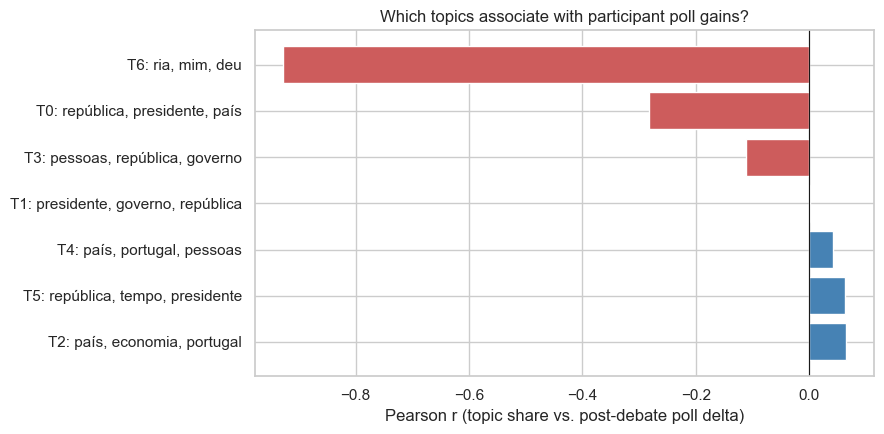

In [29]:
# Per (video, candidate, topic) -> share of that candidate's segments in topic during that debate.
debate_cand_topic = (speech_lab[speech_lab['candidate'].isin(candidates_present)]
                     .groupby(['video', 'candidate', 'topic'])
                     .size().reset_index(name='count'))
total = debate_cand_topic.groupby(['video', 'candidate'])['count'].transform('sum')
debate_cand_topic['share'] = debate_cand_topic['count'] / total

# Bring in participant/non-participant flag and delta from Section 5b.
joined = debate_cand_topic.merge(
    delta_df[['video', 'candidate', 'delta', 'is_debate_participant']].dropna(subset=['delta']),
    on=['video', 'candidate'])
joined = joined[joined['is_debate_participant']]

corr_rows = []
for k in range(K_TOPICS):
    sub = joined[joined['topic'] == k]
    if len(sub) < 5:
        continue
    r = sub[['share', 'delta']].corr().iloc[0, 1]
    corr_rows.append({
        'topic': k,
        'topic_label': topic_labels[k],
        'n': len(sub),
        'pearson_r': float(r),
        'mean_share': sub['share'].mean(),
    })
corr_df = pd.DataFrame(corr_rows).sort_values('pearson_r', ascending=False)

print('Correlation between topic share and post-debate participant poll delta:')
if len(corr_df):
    display(corr_df.round({'pearson_r': 3, 'mean_share': 3}))

    fig, ax = plt.subplots(figsize=(9, 4.5))
    colors = ['steelblue' if r >= 0 else 'indianred' for r in corr_df['pearson_r']]
    ax.barh(corr_df['topic_label'], corr_df['pearson_r'], color=colors)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel('Pearson r (topic share vs. post-debate poll delta)')
    ax.set_title('Which topics associate with participant poll gains?')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough matched topic/poll observations to compute correlations.')


## 8. Data quality and sanity checks

Conditions that should hold before this notebook is used downstream.

In [30]:
empty = (speech_lab['transcript'].fillna('').str.strip() == '').sum()
shapes = speech_lab['text_embedding'].apply(lambda v: np.asarray(v).shape)
unique_shapes = shapes.unique()
join_loss = speech_lab['candidate'].isna().sum()
low_participant_rows = debate_label_diag[debate_label_diag['min_candidate_word_share'] < 0.10]
rate_corr = np.nan
if {'speechrate', 'words_per_sec'}.issubset(speech_lab.columns):
    rate_data = speech_lab.dropna(subset=['speechrate', 'words_per_sec'])
    if len(rate_data) > 2:
        rate_corr = rate_data[['speechrate', 'words_per_sec']].corr().iloc[0, 1]

print(f'Total debate speech segments:         {len(speech_lab)}')
print(f'Empty transcripts:                    {empty}')
print(f'Embedding shapes seen:                {list(unique_shapes)}')
print(f'Speech segments without candidate:    {join_loss}')
print(f'Mean tokens / segment:                {speech_lab["word_count"].mean():.1f}')
print(f'Median tokens / segment:              {speech_lab["word_count"].median():.1f}')
print(f'Polls long-format rows:               {len(polls_long)}  (expect {len(polls) * len(cand_cols)})')
print(f'Per-video similarity symmetric:       {np.allclose(sim_video, sim_video.T)}')
print(f'Per-candidate similarity symmetric:   {np.allclose(sim_cand, sim_cand.T)}')
print(f'Lexical similarity symmetric:         {np.allclose(sim_lex, sim_lex.T)}')
print(f'Audio/text speed correlation:         {rate_corr:.3f}')
print(f'Debates with low participant coverage:{len(low_participant_rows)}')

if len(low_participant_rows):
    print('\nRows requiring caveats in candidate-level language claims:')
    print(low_participant_rows[['video', 'expected_candidates', 'min_candidate_word_share']]
          .round({'min_candidate_word_share': 3})
          .to_string(index=False))


Total debate speech segments:         843
Empty transcripts:                    0
Embedding shapes seen:                [(4096,)]
Speech segments without candidate:    0
Mean tokens / segment:                139.2
Median tokens / segment:              110.0
Polls long-format rows:               104  (expect 104)
Per-video similarity symmetric:       True
Per-candidate similarity symmetric:   True
Lexical similarity symmetric:         True
Audio/text speed correlation:         0.613
Debates with low participant coverage:4

Rows requiring caveats in candidate-level language claims:
                                        video              expected_candidates  min_candidate_word_share
          Gouveia_Melo_vs_Ventura_December_15           Gouveia_Melo | Ventura                     0.025
Cotrim_Figueiredo_vs_Gouveia_Melo_November_20 Cotrim_Figueiredo | Gouveia_Melo                     0.026
            Pinto_vs_Gouveia_Melo_November_26             Pinto | Gouveia_Melo                    